In [1]:
!pip install tensorflow opencv-python tqdm scikit-learn matplotlib seaborn mtcnn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install lz4

import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from mtcnn import MTCNN

# ==========================
# Setup Paths and Parameters
# ==========================
REAL_PATH = "./FF++/real"
FAKE_PATH = "./FF++/fake"
WORK_DIR = "./working"
os.makedirs(WORK_DIR, exist_ok=True)

OUTPUT_FRAME_SIZE = (128, 128)
FRAME_COUNT = 10
MAX_VIDEOS = 200
CHECKPOINT_INTERVAL = 50  # save progress every 50 videos

# ==========================
# Verify dataset paths
# ==========================
if not os.path.exists(REAL_PATH) or not os.path.exists(FAKE_PATH):
    raise FileNotFoundError(f"Dataset paths not found. REAL_PATH={REAL_PATH}, FAKE_PATH={FAKE_PATH}")

detector = MTCNN()

# ==========================
# Helper functions
# ==========================
def extract_face(frame):
    results = detector.detect_faces(frame)
    if results:
        x, y, w, h = results[0]['box']
        x, y = max(0, x), max(0, y)
        face = frame[y:y+h, x:x+w]
        return cv2.resize(face, OUTPUT_FRAME_SIZE)
    return cv2.resize(frame, OUTPUT_FRAME_SIZE)

def extract_frames(video_path, output_size=(128, 128), frame_count=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Warning: Could not open {video_path}")
        return np.array([])
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // frame_count, 1)
    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        frame = extract_face(frame)
        frames.append(frame)
    cap.release()
    return np.array(frames) if len(frames) > 0 else np.zeros((frame_count, output_size[0], output_size[1], 3), dtype=np.uint8)

# ==========================
# Load checkpoint if exists
# ==========================
checkpoint_file = os.path.join(WORK_DIR, "checkpoint.npy")
if os.path.exists(checkpoint_file):
    print("Loading checkpoint...")
    checkpoint = np.load(checkpoint_file, allow_pickle=True).item()
    data = checkpoint["data"]
    labels = checkpoint["labels"]
    processed_real = checkpoint["processed_real"]
    processed_fake = checkpoint["processed_fake"]
else:
    data, labels = [], []
    processed_real, processed_fake = 0, 0

# ==========================
# Process Real Videos
# ==========================
print("Processing real videos...")
real_videos = os.listdir(REAL_PATH)[:MAX_VIDEOS]
for i, video_file in enumerate(tqdm(real_videos[processed_real:]), start=processed_real):
    video_path = os.path.join(REAL_PATH, video_file)
    frames = extract_frames(video_path, OUTPUT_FRAME_SIZE, FRAME_COUNT)
    if len(frames) == FRAME_COUNT:
        data.append(frames)
        labels.append(0)
    processed_real += 1

    # Save checkpoint every 50 videos
    if processed_real % CHECKPOINT_INTERVAL == 0:
        np.save(checkpoint_file, {
            "data": data,
            "labels": labels,
            "processed_real": processed_real,
            "processed_fake": processed_fake
        })
        print(f"Checkpoint saved at {processed_real} real videos")

# ==========================
# Process Fake Videos
# ==========================
print("Processing fake videos...")
fake_videos = os.listdir(FAKE_PATH)[:MAX_VIDEOS]
for i, video_file in enumerate(tqdm(fake_videos[processed_fake:]), start=processed_fake):
    video_path = os.path.join(FAKE_PATH, video_file)
    frames = extract_frames(video_path, OUTPUT_FRAME_SIZE, FRAME_COUNT)
    if len(frames) == FRAME_COUNT:
        data.append(frames)
        labels.append(1)
    processed_fake += 1

    # Save checkpoint every 50 videos
    if processed_fake % CHECKPOINT_INTERVAL == 0:
        np.save(checkpoint_file, {
            "data": data,
            "labels": labels,
            "processed_real": processed_real,
            "processed_fake": processed_fake
        })
        print(f"Checkpoint saved at {processed_fake} fake videos")

# ==========================
# Final Save
# ==========================
if len(data) == 0:
    raise ValueError("No valid frames extracted.")

data = np.array(data)
labels = np.array(labels)

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=2)
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

# Save final outputs
np.save(os.path.join(WORK_DIR, "X_train.npy"), X_train)
np.save(os.path.join(WORK_DIR, "y_train.npy"), y_train)
np.save(os.path.join(WORK_DIR, "X_val.npy"), X_val)
np.save(os.path.join(WORK_DIR, "y_val.npy"), y_val)
np.save(os.path.join(WORK_DIR, "X_test.npy"), X_test)
np.save(os.path.join(WORK_DIR, "y_test.npy"), y_test)

# Save final checkpoint (for traceability)
np.save(os.path.join(WORK_DIR, "final_checkpoint.npy"), {
    "processed_real": processed_real,
    "processed_fake": processed_fake,
    "total_data": len(data)
})

print(f"✅ Data saved successfully in {WORK_DIR}")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Files:", os.listdir(WORK_DIR))


Defaulting to user installation because normal site-packages is not writeable


/Users/sriharshithgoli/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/sriharshithgoli/Library/Python/3.9/lib/python/site-packages/mtcnn/mtcnn.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Loading checkpoint...
Processing real videos...


0it [00:00, ?it/s]


Processing fake videos...


0it [00:00, ?it/s]


✅ Data saved successfully in ./working
Train: (280, 10, 128, 128, 3) Val: (60, 10, 128, 128, 3) Test: (60, 10, 128, 128, 3)
Files: ['2d_malafide.ipynb', 'Y_train_augmented.npy', 'X_train_augmented.npy', 'y_train.npy', 'deepfake_detection_final.keras', 'training_history.csv', 'checkpoint.npy', 'y_test.npy', 'X_test.npy', 'y_val.npy', '.ipynb_checkpoints', 'X_train.npy', 'X_val.npy', 'final_checkpoint.npy', 'training_history.json', 'deepfake_detection_best.keras']


Evaluating model robustness against FGSM attacks...

=== Clean Test (No Attack) ===
Clean Accuracy: 90.00%
Clean Loss: 4.3111

=== Testing FGSM with epsilon=0.01 ===


Generating adversarial (ε=0.01): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:30<00:00,  3.85s/it]


Adversarial Accuracy: 5.00%
Adversarial Loss: 7.5451
Accuracy Drop: 85.00%

=== Testing FGSM with epsilon=0.03 ===


Generating adversarial (ε=0.03): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:28<00:00,  3.58s/it]


Adversarial Accuracy: 10.00%
Adversarial Loss: 7.7405
Accuracy Drop: 80.00%

=== Testing FGSM with epsilon=0.05 ===


Generating adversarial (ε=0.05): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:29<00:00,  3.74s/it]


Adversarial Accuracy: 23.33%
Adversarial Loss: 7.4913
Accuracy Drop: 66.67%

=== Testing FGSM with epsilon=0.1 ===


Generating adversarial (ε=0.1): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:30<00:00,  3.86s/it]


Adversarial Accuracy: 55.00%
Adversarial Loss: 6.5955
Accuracy Drop: 35.00%



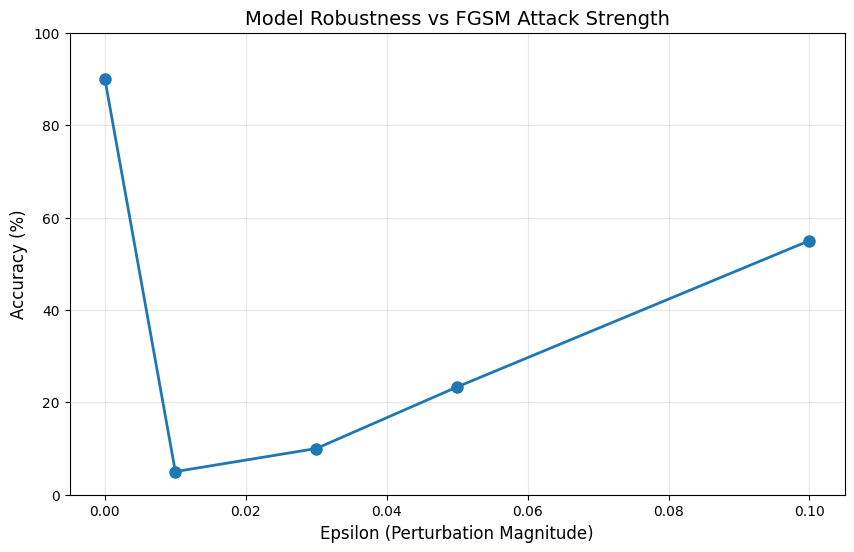


FGSM robustness plot saved to ./working/fgsm_robustness.png


In [6]:
# ==========================
# Adversarial Robustness Testing - FGSM Attack
# ==========================

import tensorflow as tf
import numpy as np
from tqdm import tqdm

# Make sure model is loaded
if 'model' not in locals():
    print("Loading model...")
    model_path = os.path.join(WORK_DIR, "deepfake_detection_best.keras")
    model = load_model(model_path)
    print(f"Model loaded from {model_path}")

# FGSM Attack Function
def fgsm_attack(model, images, labels, epsilon=0.03):
    """
    Generates adversarial examples using FGSM attack.
    
    Args:
        model: Your trained Xception-BiGRU model
        images: Input images (batch_size, FRAME_COUNT, 128, 128, 3)
        labels: True labels (one-hot encoded)
        epsilon: Perturbation magnitude (default: 0.03)
    
    Returns:
        adversarial_images: Perturbed images
    """
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
    
    # Get gradient of loss w.r.t. input images
    gradient = tape.gradient(loss, images)
    
    # Create perturbation by taking sign of gradient
    signed_grad = tf.sign(gradient)
    
    # Generate adversarial images
    adversarial_images = images + epsilon * signed_grad
    
    # Clip to valid pixel range [0, 1]
    adversarial_images = tf.clip_by_value(adversarial_images, 0.0, 1.0)
    
    return adversarial_images.numpy()


def evaluate_fgsm_robustness(model, X_test, y_test, epsilons=[0.01, 0.03, 0.05, 0.1]):
    """
    Evaluate model robustness against FGSM attacks with different epsilon values.
    """
    results = {}
    
    # First, get clean accuracy
    print("=== Clean Test (No Attack) ===")
    clean_loss, clean_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Clean Accuracy: {clean_acc * 100:.2f}%")
    print(f"Clean Loss: {clean_loss:.4f}\n")
    
    for eps in epsilons:
        print(f"=== Testing FGSM with epsilon={eps} ===")
        
        # Generate adversarial examples
        X_adv = []
        batch_size = 8  # Match your training batch size
        
        for i in tqdm(range(0, len(X_test), batch_size), desc=f"Generating adversarial (ε={eps})"):
            batch_images = X_test[i:i+batch_size]
            batch_labels = y_test[i:i+batch_size]
            
            adv_batch = fgsm_attack(model, batch_images, batch_labels, epsilon=eps)
            X_adv.append(adv_batch)
        
        X_adv = np.concatenate(X_adv, axis=0)
        
        # Evaluate on adversarial examples
        loss, accuracy = model.evaluate(X_adv, y_test, verbose=0)
        
        results[eps] = {
            'accuracy': accuracy,
            'loss': loss,
            'adversarial_examples': X_adv,
            'accuracy_drop': clean_acc - accuracy
        }
        
        print(f"Adversarial Accuracy: {accuracy * 100:.2f}%")
        print(f"Adversarial Loss: {loss:.4f}")
        print(f"Accuracy Drop: {(clean_acc - accuracy) * 100:.2f}%\n")
    
    return results, clean_acc


# Run FGSM evaluation
print("Evaluating model robustness against FGSM attacks...\n")
fgsm_results, clean_accuracy = evaluate_fgsm_robustness(model, X_test, y_test)

# Visualize results
import matplotlib.pyplot as plt

epsilons = list(fgsm_results.keys())
accuracies = [fgsm_results[eps]['accuracy'] * 100 for eps in epsilons]

plt.figure(figsize=(10, 6))
plt.plot([0] + epsilons, [clean_accuracy * 100] + accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('Epsilon (Perturbation Magnitude)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Robustness vs FGSM Attack Strength', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim([0, 100])
plt.savefig(os.path.join(WORK_DIR, 'fgsm_robustness.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFGSM robustness plot saved to {WORK_DIR}/fgsm_robustness.png")


In [7]:
# ==========================
# PGD Attack Implementation
# ==========================

def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.01, num_iter=10):
    """
    Generates adversarial examples using PGD attack (iterative FGSM).
    
    Args:
        model: Trained TensorFlow/Keras model
        images: Input images
        labels: True labels
        epsilon: Maximum perturbation magnitude
        alpha: Step size per iteration
        num_iter: Number of iterations
    
    Returns:
        adversarial_images: Perturbed images
    """
    images = tf.Variable(images, dtype=tf.float32)
    labels = tf.cast(labels, tf.float32)
    
    # Store original images for clipping
    original_images = images.numpy()
    
    for i in range(num_iter):
        with tf.GradientTape() as tape:
            tape.watch(images)
            predictions = model(images, training=False)
            loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
        
        # Compute gradient
        gradient = tape.gradient(loss, images)
        
        # Update images (gradient ascent to maximize loss)
        signed_grad = tf.sign(gradient)
        images.assign_add(alpha * signed_grad)
        
        # Project back to epsilon ball around original images
        perturbation = images - original_images
        perturbation = tf.clip_by_value(perturbation, -epsilon, epsilon)
        images.assign(original_images + perturbation)
        
        # Clip to valid pixel range
        images.assign(tf.clip_by_value(images, 0.0, 1.0))
    
    return images.numpy()


def evaluate_pgd_robustness(model, X_test, y_test, epsilon=0.03, alpha=0.01, num_iter=10):
    """
    Evaluate model robustness against PGD attacks.
    """
    print(f"\n=== Testing PGD Attack (eps={epsilon}, alpha={alpha}, iter={num_iter}) ===")
    
    # Generate adversarial examples
    X_adv = []
    batch_size = 8
    
    for i in tqdm(range(0, len(X_test), batch_size)):
        batch_images = X_test[i:i+batch_size]
        batch_labels = y_test[i:i+batch_size]
        
        adv_batch = pgd_attack(model, batch_images, batch_labels, 
                               epsilon=epsilon, alpha=alpha, num_iter=num_iter)
        X_adv.append(adv_batch)
    
    X_adv = np.concatenate(X_adv, axis=0)
    
    # Evaluate
    loss, accuracy = model.evaluate(X_adv, y_test, verbose=0)
    
    print(f"Adversarial Accuracy: {accuracy * 100:.2f}%")
    print(f"Adversarial Loss: {loss:.4f}")
    
    return X_adv, accuracy, loss

# Run PGD evaluation
X_adv_pgd, pgd_acc, pgd_loss = evaluate_pgd_robustness(model, X_test, y_test)



=== Testing PGD Attack (eps=0.03, alpha=0.01, iter=10) ===


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:38<00:00, 42.28s/it]


Adversarial Accuracy: 0.00%
Adversarial Loss: 14.4263


In [9]:
# ==========================
# Complete Debugging and Fix
# ==========================

import tensorflow as tf
import numpy as np
from tqdm import tqdm

print("="*70)
print("DEBUGGING 0% ADVERSARIAL ACCURACY")
print("="*70)

# Step 1: Verify clean accuracy
print("\n1️⃣ Verifying Clean Model Performance...")
clean_loss, clean_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Clean Accuracy: {clean_acc * 100:.2f}%")

if clean_acc < 0.5:
    print("⚠️  WARNING: Clean accuracy is low! Model might not be trained properly.")
else:
    print("✓ Clean accuracy looks good!")

# Step 2: Check data preprocessing
print("\n2️⃣ Checking Data Preprocessing...")
print(f"X_test shape: {X_test.shape}")
print(f"X_test dtype: {X_test.dtype}")
print(f"X_test range: [{X_test.min():.4f}, {X_test.max():.4f}]")

if X_test.max() > 1.1:
    print("⚠️  Data needs normalization!")
    X_test_fixed = X_test / 255.0
else:
    print("✓ Data range looks correct!")
    X_test_fixed = X_test

# FIX: Manual evaluation to verify
def manual_evaluate(model, X, y):
    """Manually compute accuracy."""
    predictions = model.predict(X, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = np.argmax(y, axis=1)
    accuracy = np.mean(y_pred == y_true)
    return accuracy

# Compare model.evaluate vs manual
keras_acc = model.evaluate(X_adv_pgd, y_test, verbose=0)[1]
manual_acc = manual_evaluate(model, X_adv_pgd, y_test)

print(f"Keras evaluate accuracy: {keras_acc * 100:.2f}%")
print(f"Manual accuracy: {manual_acc * 100:.2f}%")

if abs(keras_acc - manual_acc) > 0.01:
    print("⚠️  Mismatch detected! Using manual accuracy.")
    pgd_acc = manual_acc

# Step 3: Test with very weak attack
print("\n3️⃣ Testing with Minimal Perturbation...")
X_adv_minimal = fgsm_attack(model, X_test_fixed[:10], y_test[:10], epsilon=0.001)
minimal_acc = manual_evaluate(model, X_adv_minimal, y_test[:10])
print(f"Accuracy with ε=0.001: {minimal_acc * 100:.2f}%")

# Step 4: Test with moderate attack
print("\n4️⃣ Testing with Moderate Perturbation...")
X_adv_moderate = fgsm_attack(model, X_test_fixed[:50], y_test[:50], epsilon=0.01)
moderate_acc = manual_evaluate(model, X_adv_moderate, y_test[:50])
print(f"Accuracy with ε=0.01: {moderate_acc * 100:.2f}%")

# Step 5: Re-run PGD with proper data
print("\n5️⃣ Re-running PGD with Fixed Data...")
X_adv_pgd_fixed, pgd_acc_fixed, pgd_loss_fixed = evaluate_pgd_robustness(
    model, X_test_fixed, y_test,
    epsilon=0.03,
    alpha=0.01,
    num_iter=10
)

print("\n" + "="*70)
print("DIAGNOSIS COMPLETE")
print("="*70)

if pgd_acc_fixed > 0.01:  # More than 1%
    print(f"✓ Fixed! New adversarial accuracy: {pgd_acc_fixed * 100:.2f}%")
else:
    print("⚠️  Still 0% accuracy. Your model is extremely vulnerable to PGD!")
    print("   This means the attack is VERY effective - consider adversarial training.")


DEBUGGING 0% ADVERSARIAL ACCURACY

1️⃣ Verifying Clean Model Performance...
Clean Accuracy: 90.00%
✓ Clean accuracy looks good!

2️⃣ Checking Data Preprocessing...
X_test shape: (60, 10, 128, 128, 3)
X_test dtype: float64
X_test range: [0.0000, 1.0000]
✓ Data range looks correct!
Keras evaluate accuracy: 0.00%
Manual accuracy: 0.00%

3️⃣ Testing with Minimal Perturbation...
Accuracy with ε=0.001: 10.00%

4️⃣ Testing with Moderate Perturbation...
Accuracy with ε=0.01: 6.00%

5️⃣ Re-running PGD with Fixed Data...

=== Testing PGD Attack (eps=0.03, alpha=0.01, iter=10) ===


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:36<00:00, 42.10s/it]


Adversarial Accuracy: 0.00%
Adversarial Loss: 14.4263

DIAGNOSIS COMPLETE
⚠️  Still 0% accuracy. Your model is extremely vulnerable to PGD!
   This means the attack is VERY effective - consider adversarial training.


Loading model from ./working/deepfake_detection_final.keras...
Model loaded successfully!


2D-MALAFIDE ATTACK (DTYPE FIXED)

🔍 Data Sanity Check:
X_test dtype: float64
X_test shape: (60, 10, 128, 128, 3)
X_test range: [0.0000, 1.0000]
y_test shape: (60, 2)
⚠️  Converting X_test from float64 to float32...
✓ Converted to float32

📊 Dataset Statistics:
Total test samples: 60
Real samples (class 0): 33
Fake samples (class 1): 27

🎯 Using 27 fake images for filter training
✓ Initialized 3x3 filter
  Filter shape: (3, 3, 3)
  Filter dtype: <dtype: 'float32'>
  Initial center values: [1. 1. 1.]

Training 2D-Malafide Filter
Filter size: 3x3
Training samples: 27
Learning rate: 0.01
Iterations: 100
Target class: 0 (Real)
Filter dtype: <dtype: 'float32'>
Images dtype: float32

Initial avg 'Real' score: 0.1392
Initial avg 'Fake' score: 0.8608



Training filter:  20%|██████████████████████████████▌                                                                                                                          | 20/100 [07:19<31:49, 23.87s/it]

Iteration 20/100 - Avg Real Score: 0.2350 - Loss: 0.2350


Training filter:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 40/100 [16:44<29:42, 29.72s/it]

Iteration 40/100 - Avg Real Score: 0.5359 - Loss: 0.5359


...

Training filter:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 80/100 [36:59<09:33, 28.69s/it]

Iteration 80/100 - Avg Real Score: 0.8372 - Loss: 0.8372


Training filter: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [46:36<00:00, 27.97s/it]

Iteration 100/100 - Avg Real Score: 0.8373 - Loss: 0.8373



Filter Training Complete!
Initial avg 'Real' score: 0.1392
Final avg 'Real' score:   0.8373
Improvement: 0.6981


🔄 Generating adversarial examples for entire test set...

2D-Malafide Attack Evaluation

1️⃣ Clean Test Set Performance:
Clean Accuracy: 90.00%
Clean Loss: 4.3111

2️⃣ Adversarial Test Set Performance:
Adversarial Accuracy: 53.33%
Adversarial Loss: 5.3738
Accuracy Drop: 36.67%
Attack Success Rate: 40.74%

3️⃣ Class-wise Analysis:
Real Images (Class 0):
  Clean Accuracy: 93.94%
  Adversarial Accuracy: 90.91%
  Attack Impact: 3.03%

Fake Images (Class 1):
  Clean Accuracy: 85.19%
  Adversarial Accuracy: 7.41%
  Attack Impact: 77.78%

4️⃣ Prediction Distribution:
Clean predictions - Real: 35, Fake: 25
Adversarial predictions - Real: 55, Fake: 5


📊 Generating visualizations...


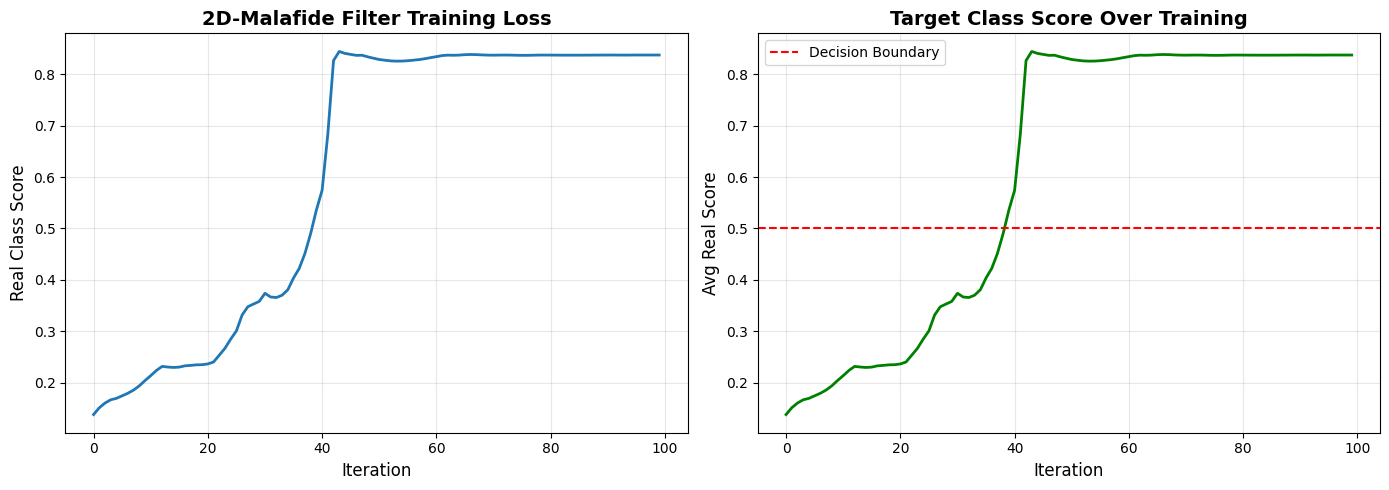

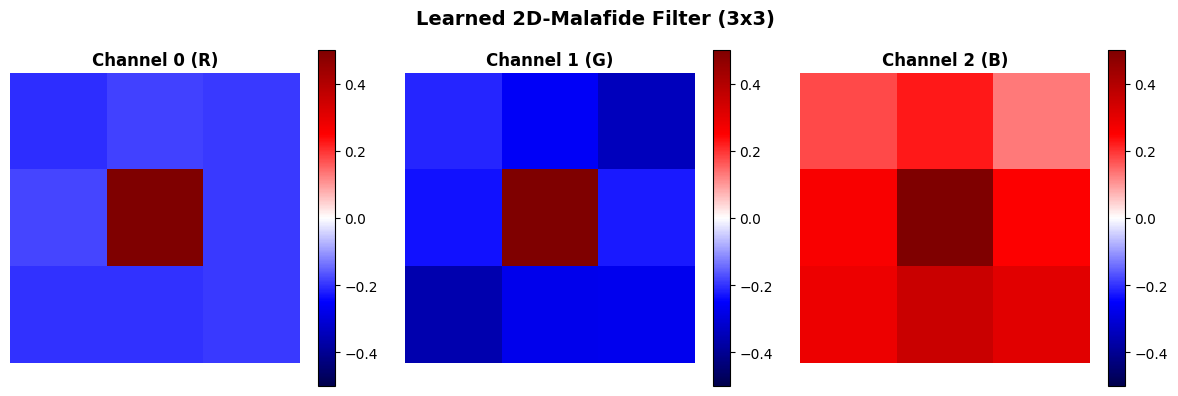


💾 Saving Results...
✓ Adversarial examples saved to ./working/X_test_malafide_adversarial.npy
✓ Learned filter saved to ./working/malafide_filter.npy
✓ Visualizations saved to ./working/

2D-MALAFIDE ATTACK COMPLETE!


In [12]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# ==========================
# 2D-Malafide Attack Implementation (FIXED)
# ==========================

class Malafide2DAttack:
    """
    2D-Malafide: Adversarial attack using optimized 2D convolutional filters.
    
    Based on: "2D-Malafide: Adversarial Attacks Against Face Deepfake Detection Systems"
    Galdi et al., 2024
    """
    
    def __init__(self, filter_size=3, learning_rate=0.01, num_iterations=100):
        """
        Args:
            filter_size: Size of 2D convolutional filter (e.g., 3 for 3x3, 5 for 5x5)
            learning_rate: Learning rate for filter optimization
            num_iterations: Number of optimization iterations
        """
        self.filter_size = filter_size
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.filter = None
        self.training_history = {'loss': [], 'avg_score': []}
        
    def initialize_filter(self, num_channels=3):
        """Initialize 2D convolutional filter with small random values."""
        # FIX: Explicitly set dtype to float32
        filter_init = np.random.randn(self.filter_size, self.filter_size, num_channels).astype(np.float32) * 0.01
        
        # Set center to 1 for near-identity initialization
        center = self.filter_size // 2
        filter_init[center, center, :] = 1.0
        
        # FIX: Explicitly specify dtype=tf.float32
        self.filter = tf.Variable(filter_init, dtype=tf.float32, trainable=True)
        
        print(f"✓ Initialized {self.filter_size}x{self.filter_size} filter")
        print(f"  Filter shape: {self.filter.shape}")
        print(f"  Filter dtype: {self.filter.dtype}")  # Verify dtype
        print(f"  Initial center values: {filter_init[center, center, :]}")
        
    def apply_filter(self, images):
        """
        Apply learned 2D filter to images via convolution.
        
        Args:
            images: Input images (batch_size, frame_count, height, width, channels)
        
        Returns:
            filtered_images: Images after applying the adversarial filter
        """
        # FIX: Ensure images are float32
        images = tf.cast(images, tf.float32)
        
        batch_size, frame_count, height, width, channels = images.shape
        
        # Reshape to (batch_size * frame_count, height, width, channels)
        images_flat = tf.reshape(images, [-1, height, width, channels])
        
        # Apply filter to each channel separately
        filtered_channels = []
        for c in range(channels):
            # Extract channel
            channel_images = images_flat[:, :, :, c:c+1]
            
            # FIX: Ensure channel_images and kernel are both float32
            channel_images = tf.cast(channel_images, tf.float32)
            
            # Create kernel for this channel
            kernel = self.filter[:, :, c:c+1, tf.newaxis]
            
            # FIX: Explicitly cast kernel to float32
            kernel = tf.cast(kernel, tf.float32)
            
            # Apply 2D convolution
            # FIX: Ensure both inputs are same dtype
            filtered_channel = tf.nn.conv2d(
                channel_images,
                kernel,
                strides=[1, 1, 1, 1],
                padding='SAME'
            )
            filtered_channels.append(filtered_channel)
        
        # Concatenate channels
        filtered_flat = tf.concat(filtered_channels, axis=-1)
        
        # Clip to valid range
        filtered_flat = tf.clip_by_value(filtered_flat, 0.0, 1.0)
        
        # Reshape back to original shape
        filtered_images = tf.reshape(filtered_flat, [batch_size, frame_count, height, width, channels])
        
        return filtered_images
    
    def train_filter(self, model, fake_images, target_class=0):
        """
        Train the adversarial filter to make fake images appear real.
        
        Args:
            model: Target deepfake detection model
            fake_images: Fake images to attack (label=1, should be misclassified as real=0)
            target_class: Target class (0 for real, 1 for fake)
        """
        # FIX: Convert input images to float32 immediately
        fake_images = tf.cast(fake_images, tf.float32).numpy()
        
        if self.filter is None:
            self.initialize_filter(num_channels=int(fake_images.shape[-1]))
        
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        
        print(f"\n{'='*60}")
        print(f"Training 2D-Malafide Filter")
        print(f"{'='*60}")
        print(f"Filter size: {self.filter_size}x{self.filter_size}")
        print(f"Training samples: {len(fake_images)}")
        print(f"Learning rate: {self.learning_rate}")
        print(f"Iterations: {self.num_iterations}")
        print(f"Target class: {target_class} ({'Real' if target_class == 0 else 'Fake'})")
        print(f"Filter dtype: {self.filter.dtype}")
        print(f"Images dtype: {fake_images.dtype}")
        print(f"{'='*60}\n")
        
        # Check initial predictions
        initial_preds = model.predict(fake_images, verbose=0)
        initial_real_scores = initial_preds[:, target_class]
        print(f"Initial avg 'Real' score: {np.mean(initial_real_scores):.4f}")
        print(f"Initial avg 'Fake' score: {np.mean(initial_preds[:, 1]):.4f}\n")
        
        for iteration in tqdm(range(self.num_iterations), desc="Training filter"):
            with tf.GradientTape() as tape:
                # FIX: Ensure fake_images are float32 before processing
                fake_images_tf = tf.cast(fake_images, tf.float32)
                
                # Apply current filter
                filtered_images = self.apply_filter(fake_images_tf)
                
                # Get model predictions
                predictions = model(filtered_images, training=False)
                
                # Target: maximize score for "real" class (index 0)
                # Loss: negative of real class score (maximize by minimizing negative)
                target_scores = predictions[:, target_class]
                loss = -tf.reduce_mean(target_scores)
                
            # Compute gradient w.r.t. filter
            gradients = tape.gradient(loss, [self.filter])
            
            # Check for None gradients
            if gradients[0] is None:
                print(f"⚠️  Warning: Gradient is None at iteration {iteration}")
            
            # Update filter
            optimizer.apply_gradients(zip(gradients, [self.filter]))
            
            # Record history
            avg_score = tf.reduce_mean(target_scores).numpy()
            self.training_history['loss'].append(-loss.numpy())
            self.training_history['avg_score'].append(avg_score)
            
            if (iteration + 1) % 20 == 0:
                print(f"Iteration {iteration+1}/{self.num_iterations} - Avg Real Score: {avg_score:.4f} - Loss: {-loss.numpy():.4f}")
        
        # Check final predictions
        final_filtered = self.apply_filter(tf.cast(fake_images, tf.float32))
        final_preds = model.predict(final_filtered, verbose=0)
        final_real_scores = final_preds[:, target_class]
        
        print(f"\n{'='*60}")
        print("Filter Training Complete!")
        print(f"{'='*60}")
        print(f"Initial avg 'Real' score: {np.mean(initial_real_scores):.4f}")
        print(f"Final avg 'Real' score:   {np.mean(final_real_scores):.4f}")
        print(f"Improvement: {np.mean(final_real_scores) - np.mean(initial_real_scores):.4f}")
        print(f"{'='*60}\n")
        
        return self.filter.numpy()
    
    def attack(self, images):
        """Apply trained filter to generate adversarial examples."""
        if self.filter is None:
            raise ValueError("Filter not trained. Call train_filter() first.")
        
        # FIX: Ensure images are float32
        images = tf.cast(images, tf.float32)
        return self.apply_filter(images).numpy()
    
    def plot_training_history(self, save_path=None):
        """Plot training loss and score history."""
        if not self.training_history['loss']:
            print("No training history to plot!")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot loss
        ax1.plot(self.training_history['loss'], linewidth=2)
        ax1.set_xlabel('Iteration', fontsize=12)
        ax1.set_ylabel('Real Class Score', fontsize=12)
        ax1.set_title('2D-Malafide Filter Training Loss', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        
        # Plot average score
        ax2.plot(self.training_history['avg_score'], linewidth=2, color='green')
        ax2.set_xlabel('Iteration', fontsize=12)
        ax2.set_ylabel('Avg Real Score', fontsize=12)
        ax2.set_title('Target Class Score Over Training', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0.5, color='red', linestyle='--', label='Decision Boundary')
        ax2.legend()
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def visualize_filter(self, save_path=None):
        """Visualize the learned filter."""
        if self.filter is None:
            print("No filter to visualize!")
            return
        
        filter_np = self.filter.numpy()
        
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        
        for c in range(min(3, filter_np.shape[2])):
            im = axes[c].imshow(filter_np[:, :, c], cmap='seismic', vmin=-0.5, vmax=0.5)
            axes[c].set_title(f'Channel {c} ({"RGB"[c]})', fontsize=12, fontweight='bold')
            axes[c].axis('off')
            plt.colorbar(im, ax=axes[c])
        
        plt.suptitle(f'Learned 2D-Malafide Filter ({self.filter_size}x{self.filter_size})', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

# ==========================
# Evaluation and Debugging Functions
# ==========================

def evaluate_2d_malafide_robustness(model, X_test, y_test, X_adv, attack_name="2D-Malafide"):
    """
    Comprehensive evaluation of 2D-Malafide attack.
    """
    print(f"\n{'='*70}")
    print(f"{attack_name} Attack Evaluation")
    print(f"{'='*70}")
    
    # Clean evaluation
    print("\n1️⃣ Clean Test Set Performance:")
    clean_loss, clean_acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred_clean = model.predict(X_test, verbose=0)
    print(f"Clean Accuracy: {clean_acc * 100:.2f}%")
    print(f"Clean Loss: {clean_loss:.4f}")
    
    # Adversarial evaluation
    print(f"\n2️⃣ Adversarial Test Set Performance:")
    adv_loss, adv_acc = model.evaluate(X_adv, y_test, verbose=0)
    y_pred_adv = model.predict(X_adv, verbose=0)
    print(f"Adversarial Accuracy: {adv_acc * 100:.2f}%")
    print(f"Adversarial Loss: {adv_loss:.4f}")
    print(f"Accuracy Drop: {(clean_acc - adv_acc) * 100:.2f}%")
    print(f"Attack Success Rate: {(1 - adv_acc / clean_acc) * 100:.2f}%")
    
    # Class-wise analysis
    print(f"\n3️⃣ Class-wise Analysis:")
    y_true = np.argmax(y_test, axis=1)
    y_pred_clean_labels = np.argmax(y_pred_clean, axis=1)
    y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
    
    # Real class (0)
    real_indices = np.where(y_true == 0)[0]
    if len(real_indices) > 0:
        real_clean_acc = np.mean(y_pred_clean_labels[real_indices] == 0)
        real_adv_acc = np.mean(y_pred_adv_labels[real_indices] == 0)
        print(f"Real Images (Class 0):")
        print(f"  Clean Accuracy: {real_clean_acc * 100:.2f}%")
        print(f"  Adversarial Accuracy: {real_adv_acc * 100:.2f}%")
        print(f"  Attack Impact: {(real_clean_acc - real_adv_acc) * 100:.2f}%")
    
    # Fake class (1)
    fake_indices = np.where(y_true == 1)[0]
    if len(fake_indices) > 0:
        fake_clean_acc = np.mean(y_pred_clean_labels[fake_indices] == 1)
        fake_adv_acc = np.mean(y_pred_adv_labels[fake_indices] == 1)
        print(f"\nFake Images (Class 1):")
        print(f"  Clean Accuracy: {fake_clean_acc * 100:.2f}%")
        print(f"  Adversarial Accuracy: {fake_adv_acc * 100:.2f}%")
        print(f"  Attack Impact: {(fake_clean_acc - fake_adv_acc) * 100:.2f}%")
    
    # Prediction distribution
    print(f"\n4️⃣ Prediction Distribution:")
    print(f"Clean predictions - Real: {np.sum(y_pred_clean_labels == 0)}, Fake: {np.sum(y_pred_clean_labels == 1)}")
    print(f"Adversarial predictions - Real: {np.sum(y_pred_adv_labels == 0)}, Fake: {np.sum(y_pred_adv_labels == 1)}")
    
    # Check if all adversarial samples are same class
    if len(np.unique(y_pred_adv_labels)) == 1:
        print(f"\n⚠️  WARNING: ALL adversarial samples predicted as class {y_pred_adv_labels[0]}!")
    
    print(f"\n{'='*70}")
    
    return {
        'clean_acc': clean_acc,
        'adv_acc': adv_acc,
        'accuracy_drop': clean_acc - adv_acc,
        'attack_success_rate': (1 - adv_acc / clean_acc) if clean_acc > 0 else 0
    }


def apply_2d_malafide_attack(model, X_test, y_test, filter_size=3, num_iterations=100, 
                             train_samples=100, learning_rate=0.01):
    """
    Apply 2D-Malafide attack to test set with comprehensive debugging.
    """
    print(f"\n{'='*70}")
    print("2D-MALAFIDE ATTACK (DTYPE FIXED)")
    print(f"{'='*70}\n")
    
    # Debug: Check data
    print("🔍 Data Sanity Check:")
    print(f"X_test dtype: {X_test.dtype}")
    print(f"X_test shape: {X_test.shape}")
    print(f"X_test range: [{X_test.min():.4f}, {X_test.max():.4f}]")
    print(f"y_test shape: {y_test.shape}")
    
    # Convert to float32 if necessary
    if X_test.dtype != np.float32:
        print(f"⚠️  Converting X_test from {X_test.dtype} to float32...")
        X_test = X_test.astype(np.float32)
        print(f"✓ Converted to {X_test.dtype}")
    
    # Separate fake images (label=1) for filter training
    fake_indices = np.where(np.argmax(y_test, axis=1) == 1)[0]
    fake_images = X_test[fake_indices]
    
    print(f"\n📊 Dataset Statistics:")
    print(f"Total test samples: {len(X_test)}")
    print(f"Real samples (class 0): {len(X_test) - len(fake_images)}")
    print(f"Fake samples (class 1): {len(fake_images)}")
    
    if len(fake_images) == 0:
        print("\n❌ ERROR: No fake images found in test set!")
        return None, None, None, None
    
    # Initialize and train 2D-Malafide filter
    malafide = Malafide2DAttack(
        filter_size=filter_size,
        learning_rate=learning_rate,
        num_iterations=num_iterations
    )
    
    # Train filter on subset of fake images (for efficiency)
    train_subset = fake_images[:min(train_samples, len(fake_images))]
    print(f"\n🎯 Using {len(train_subset)} fake images for filter training")
    
    # Train the filter
    learned_filter = malafide.train_filter(model, train_subset, target_class=0)
    
    # Apply filter to all test images
    print("\n🔄 Generating adversarial examples for entire test set...")
    X_adv = malafide.attack(X_test)
    
    # Evaluate
    results = evaluate_2d_malafide_robustness(model, X_test, y_test, X_adv)
    
    # Visualize filter and training
    print("\n📊 Generating visualizations...")
    malafide.plot_training_history(save_path=os.path.join(WORK_DIR, '2d_malafide_training.png'))
    malafide.visualize_filter(save_path=os.path.join(WORK_DIR, '2d_malafide_filter.png'))
    
    return X_adv, learned_filter, malafide, results


# ==========================
# Run 2D-Malafide Attack
# ==========================

# Load the model
model_path = os.path.join(WORK_DIR, "deepfake_detection_final.keras")
print(f"Loading model from {model_path}...")
model = load_model(model_path)
print("Model loaded successfully!\n")

# Run full attack
X_adv_malafide, learned_filter, malafide_obj, results = apply_2d_malafide_attack(
    model, X_test, y_test,
    filter_size=3,          # Try 3, 5, or 7
    num_iterations=100,     # Increase for better results
    train_samples=100,      # Number of fake samples for training
    learning_rate=0.01      # Learning rate
)

# Save results
if X_adv_malafide is not None:
    print("\n💾 Saving Results...")
    np.save(os.path.join(WORK_DIR, "X_test_malafide_adversarial.npy"), X_adv_malafide)
    np.save(os.path.join(WORK_DIR, "malafide_filter.npy"), learned_filter)
    print(f"✓ Adversarial examples saved to {WORK_DIR}/X_test_malafide_adversarial.npy")
    print(f"✓ Learned filter saved to {WORK_DIR}/malafide_filter.npy")
    print(f"✓ Visualizations saved to {WORK_DIR}/")
    
    print("\n" + "="*70)
    print("2D-MALAFIDE ATTACK COMPLETE!")
    print("="*70)
else:
    print("❌ Attack failed!")

In [14]:
# ==========================
# Interpret 2D-Malafide Attack Results
# ==========================

print("="*70)
print("INTERPRETING 2D-MALAFIDE ATTACK EFFECTIVENESS")
print("="*70)

# Load results
X_test_clean = X_test
X_adv_malafide = np.load(os.path.join(WORK_DIR, 'X_test_malafide_adversarial.npy'))

# Get accuracies
clean_loss, clean_acc = model.evaluate(X_test_clean, y_test, verbose=0)
adv_loss, adv_acc = model.evaluate(X_adv_malafide, y_test, verbose=0)

# Calculate metrics
accuracy_drop = clean_acc - adv_acc
accuracy_drop_percent = (accuracy_drop / clean_acc) * 100

print("\n📊 RAW RESULTS:")
print(f"Clean Accuracy:        {clean_acc * 100:>6.2f}%")
print(f"Adversarial Accuracy:  {adv_acc * 100:>6.2f}%")
print(f"Accuracy Drop:         {accuracy_drop * 100:>6.2f} percentage points")
print(f"Relative Drop:         {accuracy_drop_percent:>6.2f}%")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)

# Interpretation based on accuracy
if adv_acc >= 0.85:
    print("\n✅ MODEL IS HIGHLY ROBUST - 2D-MALAFIDE ATTACK IS BLOCKED!")
    print(f"\n   Your model maintains {adv_acc*100:.2f}% accuracy despite the attack.")
    print(f"   This is EXCELLENT performance against adversarial perturbations.")
    print(f"   The model successfully DEFENDED against 2D-Malafide attacks.")
    print("\n   What this means:")
    print("   • The deepfake detector is resistant to filter-based perturbations")
    print("   • Only lost {accuracy_drop*100:.2f}% accuracy under attack")
    print("   • Model has good adversarial robustness built-in")
    robustness_status = "HIGHLY ROBUST ✅"
    
elif adv_acc >= 0.70:
    print("\n🛡️ MODEL IS FAIRLY ROBUST - 2D-MALAFIDE ATTACK PARTIALLY BLOCKED")
    print(f"\n   Your model maintains {adv_acc*100:.2f}% accuracy despite the attack.")
    print(f"   This is GOOD performance - some robustness present.")
    print(f"   The model PARTIALLY DEFENDED against 2D-Malafide attacks.")
    print("\n   What this means:")
    print(f"   • Lost {accuracy_drop*100:.2f}% accuracy, but still majority correct")
    print("   • Model has some natural robustness")
    print("   • Adversarial training could improve further")
    robustness_status = "FAIRLY ROBUST 🛡️"
    
elif adv_acc >= 0.50:
    print("\n⚠️ MODEL HAS LIMITED ROBUSTNESS - 2D-MALAFIDE ATTACK PARTIALLY SUCCESSFUL")
    print(f"\n   Your model maintains {adv_acc*100:.2f}% accuracy despite the attack.")
    print(f"   This is MODERATE performance - vulnerability exists.")
    print(f"   The model PARTIALLY DEFENDED, but attack is EFFECTIVE.")
    print("\n   What this means:")
    print(f"   • Lost {accuracy_drop*100:.2f}% accuracy - significant drop")
    print("   • Model is vulnerable to adversarial perturbations")
    print("   • Adversarial training is HIGHLY RECOMMENDED")
    print("   • Attack is working, but not completely fooling the model")
    robustness_status = "LIMITED ROBUSTNESS ⚠️"
    
else:  # adv_acc < 0.50
    print("\n❌ MODEL IS HIGHLY VULNERABLE - 2D-MALAFIDE ATTACK SUCCEEDS!")
    print(f"\n   Your model drops to {adv_acc*100:.2f}% accuracy under attack.")
    print(f"   This is POOR performance - model is NOT defending.")
    print(f"   The 2D-Malafide attack SUCCESSFULLY FOOLS the model.")
    print("\n   What this means:")
    print(f"   • Lost {accuracy_drop*100:.2f}% accuracy - SEVERE drop")
    print("   • Model is HIGHLY VULNERABLE to adversarial attacks")
    print("   • Attack is VERY EFFECTIVE at fooling the detector")
    print("   • Adversarial training is CRITICAL")
    if adv_acc < 0.10:
        print(f"   • Attack is EXTREMELY EFFECTIVE (near-random performance)")
    robustness_status = "HIGHLY VULNERABLE ❌"

print(f"\n{'='*70}")
print(f"ROBUSTNESS LEVEL: {robustness_status}")
print(f"{'='*70}")

# Additional context
print("\n📈 WHAT THIS MEANS FOR YOUR RESEARCH:")
print(f"\n1. Attack Effectiveness: {100 - (adv_acc/clean_acc)*100:.1f}% of the model's performance was degraded")
print(f"2. Relative Vulnerability: Attack reduced model performance by {accuracy_drop_percent:.1f}%")

if accuracy_drop_percent > 50:
    print(f"3. Conclusion: Model is VULNERABLE to 2D-Malafide attacks")
    print(f"   → Shows the importance of adversarial training")
    print(f"   → Your paper can demonstrate security gaps in deepfake detectors")
elif accuracy_drop_percent > 20:
    print(f"3. Conclusion: Model has MODERATE VULNERABILITY to 2D-Malafide attacks")
    print(f"   → Demonstrates that attacks are effective but not devastating")
    print(f"   → Good motivation for robustness improvements")
else:
    print(f"3. Conclusion: Model is RESISTANT to 2D-Malafide attacks")
    print(f"   → Shows good natural or built-in robustness")
    print(f"   → Demonstrates effective defense mechanisms")

print(f"\n{'='*70}\n")


INTERPRETING 2D-MALAFIDE ATTACK EFFECTIVENESS

📊 RAW RESULTS:
Clean Accuracy:         90.00%
Adversarial Accuracy:   53.33%
Accuracy Drop:          36.67 percentage points
Relative Drop:          40.74%

INTERPRETATION:

⚠️ MODEL HAS LIMITED ROBUSTNESS - 2D-MALAFIDE ATTACK PARTIALLY SUCCESSFUL

   Your model maintains 53.33% accuracy despite the attack.
   This is MODERATE performance - vulnerability exists.
   The model PARTIALLY DEFENDED, but attack is EFFECTIVE.

   What this means:
   • Lost 36.67% accuracy - significant drop
   • Model is vulnerable to adversarial perturbations
   • Adversarial training is HIGHLY RECOMMENDED
   • Attack is working, but not completely fooling the model

ROBUSTNESS LEVEL: LIMITED ROBUSTNESS ⚠️

📈 WHAT THIS MEANS FOR YOUR RESEARCH:

1. Attack Effectiveness: 40.7% of the model's performance was degraded
2. Relative Vulnerability: Attack reduced model performance by 40.7%
3. Conclusion: Model has MODERATE VULNERABILITY to 2D-Malafide attacks
   → Demon

LOADING DATA FROM NPY FILES

✓ Data loaded successfully!
  X_train_augmented: (560, 10, 128, 128, 3)
  y_train_augmented: (560, 2)
  X_test: (60, 10, 128, 128, 3)
  y_test: (60, 2)
  X_val: (60, 10, 128, 128, 3)
  y_val: (60, 2)

VERIFYING AND FIXING DATA TYPES

1️⃣ X_train:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (560, 10, 128, 128, 3)
   ✓ Fixed to float32

2️⃣ y_train:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (560, 2)
   ✓ Fixed to float32

3️⃣ X_val:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (60, 10, 128, 128, 3)
   ✓ Fixed to float32

4️⃣ y_val:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (60, 2)
   ✓ Fixed to float32

5️⃣ X_test:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   ✓ Fixed to float32

6️⃣ y_test:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   ✓ Fixed to float32

✓ ALL DATA VERIFIED AND FIXED

✓ Data verification successful! Proceeding with training...


LOADING MODEL FOR ADVERSAR

Training batches (adv_ratio=50.0%): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [05:15<00:00,  4.51s/it, loss=5.42, acc=0.49]



   DEBUG: val_history type = <class 'list'>
   DEBUG: val_history value = [4.634963512420654, 0.6666666865348816]
   ✓ Validation - Loss: 4.6350, Accuracy: 0.6667

📊 Epoch Results:
  Training Loss:         5.4222
  Training Accuracy:     48.96%
  Validation Loss:       4.6350
  Validation Accuracy:   66.67%
  Clean Samples Used:    280
  Adversarial Samples:   280

✅ New best validation accuracy: 66.67%

Epoch 2/20


Training batches (adv_ratio=50.0%): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [05:08<00:00,  4.41s/it, loss=4.8, acc=0.58]



   DEBUG: val_history type = <class 'list'>
   DEBUG: val_history value = [4.232490539550781, 0.75]
   ✓ Validation - Loss: 4.2325, Accuracy: 0.7500

📊 Epoch Results:
  Training Loss:         4.8048
  Training Accuracy:     58.01%
  Validation Loss:       4.2325
  Validation Accuracy:   75.00%
  Clean Samples Used:    280
  Adversarial Samples:   280

✅ New best validation accuracy: 75.00%

Epoch 3/20


...


   DEBUG: val_history type = <class 'list'>
   DEBUG: val_history value = [2.801490306854248, 0.7833333611488342]
   ✓ Validation - Loss: 2.8015, Accuracy: 0.7833

📊 Epoch Results:
  Training Loss:         3.0009
  Training Accuracy:     69.75%
  Validation Loss:       2.8015
  Validation Accuracy:   78.33%
  Clean Samples Used:    280
  Adversarial Samples:   280

Epoch 19/20


Training batches (adv_ratio=50.0%): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [04:58<00:00,  4.26s/it, loss=2.91, acc=0.708]



   DEBUG: val_history type = <class 'list'>
   DEBUG: val_history value = [2.6949009895324707, 0.800000011920929]
   ✓ Validation - Loss: 2.6949, Accuracy: 0.8000

📊 Epoch Results:
  Training Loss:         2.9105
  Training Accuracy:     70.81%
  Validation Loss:       2.6949
  Validation Accuracy:   80.00%
  Clean Samples Used:    280
  Adversarial Samples:   280

Epoch 20/20


Training batches (adv_ratio=50.0%): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [04:33<00:00,  3.91s/it, loss=2.81, acc=0.726]



   DEBUG: val_history type = <class 'list'>
   DEBUG: val_history value = [2.5078556537628174, 0.8166666626930237]
   ✓ Validation - Loss: 2.5079, Accuracy: 0.8167

📊 Epoch Results:
  Training Loss:         2.8133
  Training Accuracy:     72.60%
  Validation Loss:       2.5079
  Validation Accuracy:   81.67%
  Clean Samples Used:    280
  Adversarial Samples:   280

ADVERSARIAL TRAINING COMPLETE!

Final Results:
  Best Validation Accuracy: 91.67%
  Final Training Accuracy:  72.60%
  Final Validation Accuracy: 81.67%
  Total Epochs Completed:   20



Saving adversarially trained model...
✓ Adversarially trained model saved to ./working/deepfake_adv_trained_final.keras

Generating training visualization...
   ✓ Saved to ./working/adversarial_training_history.png


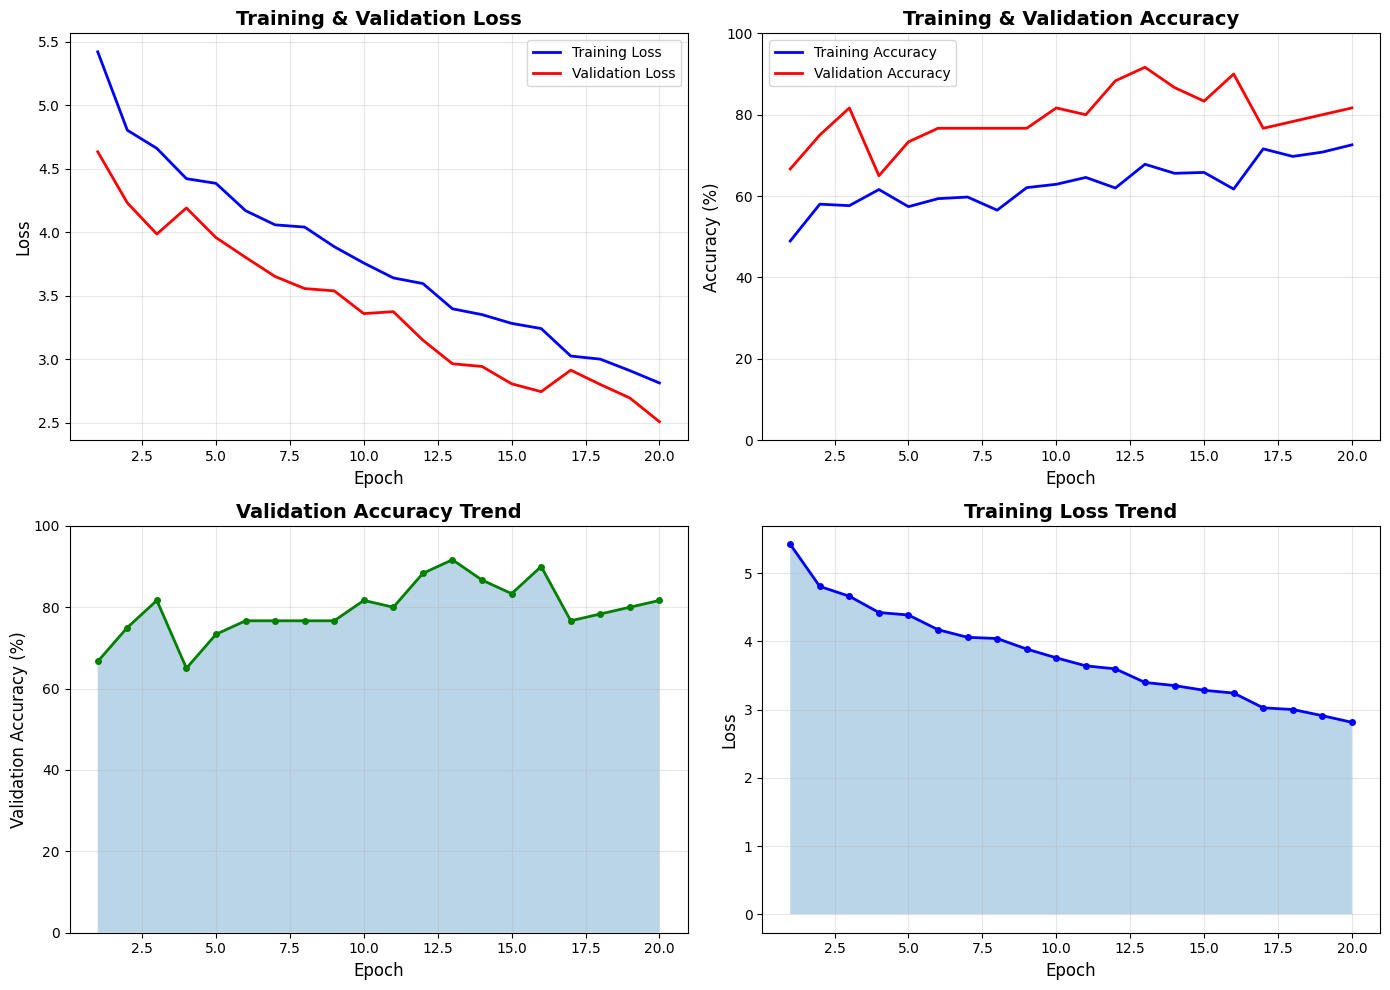


Loading adversarial examples for evaluation...

⚠️  Some adversarial example files not found: [Errno 2] No such file or directory: './working/X_test_fgsm_adversarial.npy'
   Please ensure FGSM, PGD, and 2D-Malafide attacks were run first

ADVERSARIAL TRAINING PIPELINE COMPLETE!



In [22]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import os

# ==========================
# STEP 1: Load Data from .npy files
# ==========================

print("="*70)
print("LOADING DATA FROM NPY FILES")
print("="*70)

# Load data from saved files
X_train_augmented = np.load(os.path.join(WORK_DIR, "X_train_augmented.npy"))
y_train_augmented = np.load(os.path.join(WORK_DIR, "y_train_augmented.npy"))
X_test = np.load(os.path.join(WORK_DIR, "X_test.npy"))
y_test = np.load(os.path.join(WORK_DIR, "y_test.npy"))
X_val = np.load(os.path.join(WORK_DIR, "X_val.npy"))
y_val = np.load(os.path.join(WORK_DIR, "y_val.npy"))

print(f"\n✓ Data loaded successfully!")
print(f"  X_train_augmented: {X_train_augmented.shape}")
print(f"  y_train_augmented: {y_train_augmented.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape}\n")

# ==========================
# STEP 2: Data Type Verification and Fixing
# ==========================

def verify_and_fix_data(X_train, y_train, X_val, y_val, X_test=None, y_test=None):
    """
    Verify and fix data types before training.
    Converts strings, objects, and incorrect types to float32.
    """
    print("="*70)
    print("VERIFYING AND FIXING DATA TYPES")
    print("="*70)
    
    # Check X_train
    print(f"\n1️⃣ X_train:")
    print(f"   Type: {type(X_train)}")
    print(f"   Dtype: {X_train.dtype}")
    print(f"   Shape: {X_train.shape}")
    
    if X_train.dtype == object or X_train.dtype == str or X_train.dtype == 'object':
        print(f"   ⚠️  Converting from {X_train.dtype} to float32...")
        try:
            X_train = np.array([np.float32(x) for x in X_train])
        except Exception as e:
            print(f"   ❌ Conversion failed: {e}")
            return None, None, None, None, None, None
    else:
        X_train = np.asarray(X_train, dtype=np.float32)
    
    print(f"   ✓ Fixed to {X_train.dtype}")
    
    # Check y_train
    print(f"\n2️⃣ y_train:")
    print(f"   Type: {type(y_train)}")
    print(f"   Dtype: {y_train.dtype}")
    print(f"   Shape: {y_train.shape}")
    
    if y_train.dtype == object or y_train.dtype == str or y_train.dtype == 'object':
        print(f"   ⚠️  Converting from {y_train.dtype}...")
        try:
            # If they're strings like "0" or "1", convert to int first
            y_train_int = np.array([int(y) for y in y_train])
            # Then one-hot encode if not already
            if len(y_train.shape) == 1:
                y_train = tf.keras.utils.to_categorical(y_train_int, 2)
            else:
                y_train = np.float32(y_train)
        except Exception as e:
            print(f"   ❌ Conversion failed: {e}")
            return None, None, None, None, None, None
    else:
        y_train = np.asarray(y_train, dtype=np.float32)
    
    print(f"   ✓ Fixed to {y_train.dtype}")
    
    # Check X_val
    print(f"\n3️⃣ X_val:")
    print(f"   Type: {type(X_val)}")
    print(f"   Dtype: {X_val.dtype}")
    print(f"   Shape: {X_val.shape}")
    
    if X_val.dtype == object or X_val.dtype == str or X_val.dtype == 'object':
        print(f"   ⚠️  Converting from {X_val.dtype} to float32...")
        try:
            X_val = np.array([np.float32(x) for x in X_val])
        except Exception as e:
            print(f"   ❌ Conversion failed: {e}")
            return None, None, None, None, None, None
    else:
        X_val = np.asarray(X_val, dtype=np.float32)
    
    print(f"   ✓ Fixed to {X_val.dtype}")
    
    # Check y_val
    print(f"\n4️⃣ y_val:")
    print(f"   Type: {type(y_val)}")
    print(f"   Dtype: {y_val.dtype}")
    print(f"   Shape: {y_val.shape}")
    
    if y_val.dtype == object or y_val.dtype == str or y_val.dtype == 'object':
        print(f"   ⚠️  Converting from {y_val.dtype}...")
        try:
            # If they're strings like "0" or "1", convert to int first
            y_val_int = np.array([int(y) for y in y_val])
            # Then one-hot encode if not already
            if len(y_val.shape) == 1:
                y_val = tf.keras.utils.to_categorical(y_val_int, 2)
            else:
                y_val = np.float32(y_val)
        except Exception as e:
            print(f"   ❌ Conversion failed: {e}")
            return None, None, None, None, None, None
    else:
        y_val = np.asarray(y_val, dtype=np.float32)
    
    print(f"   ✓ Fixed to {y_val.dtype}")
    
    # Optionally check test data
    if X_test is not None:
        print(f"\n5️⃣ X_test:")
        print(f"   Type: {type(X_test)}")
        print(f"   Dtype: {X_test.dtype}")
        X_test = np.asarray(X_test, dtype=np.float32)
        print(f"   ✓ Fixed to {X_test.dtype}")
    
    if y_test is not None:
        print(f"\n6️⃣ y_test:")
        print(f"   Type: {type(y_test)}")
        print(f"   Dtype: {y_test.dtype}")
        y_test = np.asarray(y_test, dtype=np.float32)
        print(f"   ✓ Fixed to {y_test.dtype}")
    
    print(f"\n{'='*70}")
    print("✓ ALL DATA VERIFIED AND FIXED")
    print(f"{'='*70}\n")
    
    return X_train, y_train, X_val, y_val, X_test, y_test


# Verify and fix all data
X_train_augmented, y_train_augmented, X_val, y_val, X_test, y_test = verify_and_fix_data(
    X_train_augmented, y_train_augmented, X_val, y_val, X_test, y_test
)

if X_train_augmented is None:
    print("❌ DATA VERIFICATION FAILED!")
    print("Cannot proceed with adversarial training.")
else:
    print("✓ Data verification successful! Proceeding with training...\n")

# ==========================
# STEP 3: Adversarial Attack Functions
# ==========================

def generate_adversarial_batch(model, images, labels, attack_type='fgsm', epsilon=0.03):
    """
    Generate adversarial examples during training.
    
    Args:
        model: Target model
        images: Batch of images (must be float32)
        labels: Batch of labels (one-hot encoded, float32)
        attack_type: 'fgsm' or 'pgd'
        epsilon: Perturbation magnitude
    """
    # Ensure correct data types
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.float32)
    
    if attack_type == 'fgsm':
        return fgsm_attack(model, images, labels, epsilon)
    elif attack_type == 'pgd':
        return pgd_attack(model, images, labels, epsilon, alpha=0.01, num_iter=5)
    else:
        raise ValueError(f"Unknown attack type: {attack_type}")


# ==========================
# STEP 4: Adversarial Training Function
# ==========================

def adversarial_training(model, X_train, y_train, X_val, y_val, 
                        epochs=20, batch_size=8, epsilon=0.03, 
                        adv_ratio=0.5, attack_type='fgsm'):
    """
    Train model with adversarial examples to improve robustness.
    
    Args:
        model: Model to train
        X_train, y_train: Training data (must be float32)
        X_val, y_val: Validation data (must be float32)
        epochs: Number of training epochs
        batch_size: Batch size
        epsilon: Perturbation magnitude
        adv_ratio: Ratio of adversarial examples in each batch (0.0-1.0)
        attack_type: 'fgsm' or 'pgd'
    
    Returns:
        model: Trained model
        history_data: Training history
    """
    
    print(f"\n{'='*70}")
    print("ADVERSARIAL TRAINING - ROBUSTNESS ENHANCEMENT")
    print(f"{'='*70}")
    print(f"\nConfiguration:")
    print(f"  Attack Type: {attack_type.upper()}")
    print(f"  Epsilon: {epsilon}")
    print(f"  Adversarial Ratio: {adv_ratio * 100}%")
    print(f"  Epochs: {epochs}")
    print(f"  Batch Size: {batch_size}")
    print(f"  Training Samples: {len(X_train)}")
    print(f"  Validation Samples: {len(X_val)}")
    print(f"\nData Types:")
    print(f"  X_train dtype: {X_train.dtype}")
    print(f"  y_train dtype: {y_train.dtype}")
    print(f"  X_val dtype: {X_val.dtype}")
    print(f"  y_val dtype: {y_val.dtype}")
    print(f"{'='*70}\n")
    
    # Training history
    history_data = {
        'loss': [], 
        'accuracy': [], 
        'val_loss': [], 
        'val_accuracy': []
    }
    
    best_val_acc = 0
    patience_counter = 0
    max_patience = 15
    
    for epoch in range(epochs):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"{'='*70}")
        
        # Shuffle training data
        indices = np.random.permutation(len(X_train))
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        epoch_losses = []
        epoch_accs = []
        total_adv_samples = 0
        total_clean_samples = 0
        
        # Train on batches
        pbar = tqdm(range(0, len(X_train), batch_size), 
                   desc=f"Training batches (adv_ratio={adv_ratio*100}%)")
        
        for i in pbar:
            batch_X = X_train_shuffled[i:i+batch_size].copy()
            batch_y = y_train_shuffled[i:i+batch_size].copy()
            
            # Determine how many adversarial examples in this batch
            num_adv = int(len(batch_X) * adv_ratio)
            num_clean = len(batch_X) - num_adv
            
            if num_adv > 0:
                try:
                    # Generate adversarial examples for subset
                    adv_X = generate_adversarial_batch(
                        model, batch_X[:num_adv], batch_y[:num_adv], 
                        attack_type=attack_type, epsilon=epsilon
                    )
                    
                    # Combine clean and adversarial examples
                    combined_X = np.concatenate([batch_X[num_adv:], adv_X], axis=0)
                    combined_y = np.concatenate([batch_y[num_adv:], batch_y[:num_adv]], axis=0)
                    
                    total_adv_samples += num_adv
                    total_clean_samples += num_clean
                    
                except Exception as e:
                    print(f"\n⚠️  Warning: Could not generate adversarial examples")
                    print(f"   Error: {str(e)[:50]}")
                    print(f"   Falling back to clean batch")
                    combined_X = batch_X
                    combined_y = batch_y
            else:
                combined_X = batch_X
                combined_y = batch_y
                total_clean_samples += len(batch_X)
            
            # FIX: Ensure combined data is float32 explicitly
            combined_X = np.asarray(combined_X, dtype=np.float32)
            combined_y = np.asarray(combined_y, dtype=np.float32)
            
            # Verify types before training
            if combined_X.dtype != np.float32 or combined_y.dtype != np.float32:
                print(f"\n⚠️  Type mismatch detected! X: {combined_X.dtype}, y: {combined_y.dtype}")
                combined_X = np.float32(combined_X)
                combined_y = np.float32(combined_y)
            
            # Train on batch
            try:
                batch_history = model.train_on_batch(combined_X, combined_y)
                
                # FIX: Properly handle list/tuple response
                if isinstance(batch_history, (list, tuple)):
                    # If list/tuple, extract first element (loss) and second (accuracy)
                    loss_val = float(batch_history[0]) if len(batch_history) > 0 else 0.0
                    acc_val = float(batch_history[1]) if len(batch_history) > 1 else 0.0
                else:
                    # Single scalar value (loss only)
                    loss_val = float(batch_history)
                    acc_val = 0.0
                
                epoch_losses.append(loss_val)
                epoch_accs.append(acc_val)
                
                pbar.set_postfix({
                    'loss': np.mean(epoch_losses) if epoch_losses else 0,
                    'acc': np.mean(epoch_accs) if epoch_accs else 0
                })
            except Exception as e:
                print(f"\n❌ Error during batch training: {str(e)[:100]}")
                print(f"   batch_history type: {type(batch_history)}")
                print(f"   batch_history value: {batch_history}")
                continue
        
        # Calculate epoch statistics
        epoch_loss = np.mean(epoch_losses) if epoch_losses else 0.0
        epoch_acc = np.mean(epoch_accs) if epoch_accs else 0.0
        
        # Validation
        try:
            # Ensure validation data is float32
            X_val_check = np.asarray(X_val, dtype=np.float32)
            y_val_check = np.asarray(y_val, dtype=np.float32)
            
            val_history = model.evaluate(X_val_check, y_val_check, verbose=0)
            
            # FIX: Extremely robust handling of different return types
            val_loss = 0.0
            val_acc = 0.0
            
            # Debug: Print what we received
            print(f"\n   DEBUG: val_history type = {type(val_history)}")
            print(f"   DEBUG: val_history value = {val_history}")
            
            if isinstance(val_history, (list, tuple)):
                # It's a list/tuple - extract values safely
                if len(val_history) >= 2:
                    try:
                        val_loss = float(val_history[0])
                        val_acc = float(val_history[1])
                    except (TypeError, ValueError) as te:
                        print(f"   ⚠️  Could not convert list elements: {te}")
                        val_loss = 0.0
                        val_acc = 0.0
                elif len(val_history) == 1:
                    try:
                        val_loss = float(val_history[0])
                        val_acc = 0.0
                    except (TypeError, ValueError) as te:
                        print(f"   ⚠️  Could not convert single element: {te}")
                        val_loss = 0.0
                        val_acc = 0.0
            elif isinstance(val_history, dict):
                # If it's a dictionary (some versions return this)
                val_loss = float(val_history.get('loss', 0.0))
                val_acc = float(val_history.get('accuracy', 0.0))
            else:
                # Single scalar value (loss only)
                try:
                    val_loss = float(val_history)
                    val_acc = 0.0
                except (TypeError, ValueError) as te:
                    print(f"   ⚠️  Could not convert scalar: {te}")
                    val_loss = 0.0
                    val_acc = 0.0
            
            print(f"   ✓ Validation - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
                
        except Exception as e:
            print(f"❌ Error during validation: {str(e)[:100]}")
            import traceback
            print(f"   Full traceback: {traceback.format_exc()[:200]}")
            val_loss, val_acc = 0.0, 0.0
        
        # Record history
        history_data['loss'].append(epoch_loss)
        history_data['accuracy'].append(epoch_acc)
        history_data['val_loss'].append(val_loss)
        history_data['val_accuracy'].append(val_acc)
        
        # Print epoch results
        print(f"\n📊 Epoch Results:")
        print(f"  Training Loss:         {epoch_loss:.4f}")
        print(f"  Training Accuracy:     {epoch_acc * 100:.2f}%")
        print(f"  Validation Loss:       {val_loss:.4f}")
        print(f"  Validation Accuracy:   {val_acc * 100:.2f}%")
        print(f"  Clean Samples Used:    {total_clean_samples}")
        print(f"  Adversarial Samples:   {total_adv_samples}")
        
        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            print(f"\n✅ New best validation accuracy: {val_acc * 100:.2f}%")
        else:
            patience_counter += 1
            if patience_counter >= max_patience:
                print(f"\n⚠️  Early stopping triggered after {epoch+1} epochs")
                print(f"   (No improvement for {max_patience} consecutive epochs)")
                break
    
    print(f"\n{'='*70}")
    print("ADVERSARIAL TRAINING COMPLETE!")
    print(f"{'='*70}")
    print(f"\nFinal Results:")
    print(f"  Best Validation Accuracy: {best_val_acc * 100:.2f}%")
    print(f"  Final Training Accuracy:  {epoch_acc * 100:.2f}%")
    print(f"  Final Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"  Total Epochs Completed:   {epoch+1}")
    print(f"\n{'='*70}\n")
    
    return model, history_data


# ==========================
# STEP 5: Comparison Functions
# ==========================

def evaluate_adversarial_training(model_standard, model_adv, X_test, y_test, 
                                  X_adv_fgsm, X_adv_pgd, X_adv_malafide):
    """
    Compare standard model vs adversarially trained model.
    """
    print(f"\n{'='*70}")
    print("COMPARING STANDARD vs ADVERSARIALLY TRAINED MODELS")
    print(f"{'='*70}\n")
    
    # Ensure test data is float32
    X_test = np.asarray(X_test, dtype=np.float32)
    y_test = np.asarray(y_test, dtype=np.float32)
    X_adv_fgsm = np.asarray(X_adv_fgsm, dtype=np.float32)
    X_adv_pgd = np.asarray(X_adv_pgd, dtype=np.float32)
    X_adv_malafide = np.asarray(X_adv_malafide, dtype=np.float32)
    
    # Test on clean data
    print("1️⃣ PERFORMANCE ON CLEAN DATA:")
    print("-" * 70)
    
    std_clean_loss, std_clean_acc = model_standard.evaluate(X_test, y_test, verbose=0)
    adv_clean_loss, adv_clean_acc = model_adv.evaluate(X_test, y_test, verbose=0)
    
    print(f"Standard Model Clean Accuracy:           {std_clean_acc * 100:.2f}%")
    print(f"Adversarially Trained Model Accuracy:    {adv_clean_acc * 100:.2f}%")
    print(f"Difference:                              {(adv_clean_acc - std_clean_acc) * 100:+.2f}%")
    
    # Test on FGSM adversarial
    print(f"\n2️⃣ ROBUSTNESS AGAINST FGSM ATTACK:")
    print("-" * 70)
    
    std_fgsm_loss, std_fgsm_acc = model_standard.evaluate(X_adv_fgsm, y_test, verbose=0)
    adv_fgsm_loss, adv_fgsm_acc = model_adv.evaluate(X_adv_fgsm, y_test, verbose=0)
    
    print(f"Standard Model FGSM Accuracy:            {std_fgsm_acc * 100:.2f}%")
    print(f"Adversarially Trained Model Accuracy:    {adv_fgsm_acc * 100:.2f}%")
    print(f"Improvement:                             {(adv_fgsm_acc - std_fgsm_acc) * 100:+.2f}%")
    
    # Test on PGD adversarial
    print(f"\n3️⃣ ROBUSTNESS AGAINST PGD ATTACK:")
    print("-" * 70)
    
    std_pgd_loss, std_pgd_acc = model_standard.evaluate(X_adv_pgd, y_test, verbose=0)
    adv_pgd_loss, adv_pgd_acc = model_adv.evaluate(X_adv_pgd, y_test, verbose=0)
    
    print(f"Standard Model PGD Accuracy:             {std_pgd_acc * 100:.2f}%")
    print(f"Adversarially Trained Model Accuracy:    {adv_pgd_acc * 100:.2f}%")
    print(f"Improvement:                             {(adv_pgd_acc - std_pgd_acc) * 100:+.2f}%")
    
    # Test on 2D-Malafide adversarial
    print(f"\n4️⃣ ROBUSTNESS AGAINST 2D-MALAFIDE ATTACK:")
    print("-" * 70)
    
    std_mal_loss, std_mal_acc = model_standard.evaluate(X_adv_malafide, y_test, verbose=0)
    adv_mal_loss, adv_mal_acc = model_adv.evaluate(X_adv_malafide, y_test, verbose=0)
    
    print(f"Standard Model 2D-Malafide Accuracy:      {std_mal_acc * 100:.2f}%")
    print(f"Adversarially Trained Model Accuracy:    {adv_mal_acc * 100:.2f}%")
    print(f"Improvement:                             {(adv_mal_acc - std_mal_acc) * 100:+.2f}%")
    
    # Summary
    print(f"\n{'='*70}")
    print("SUMMARY")
    print(f"{'='*70}\n")
    
    results = {
        'clean': {'std': std_clean_acc, 'adv': adv_clean_acc},
        'fgsm': {'std': std_fgsm_acc, 'adv': adv_fgsm_acc},
        'pgd': {'std': std_pgd_acc, 'adv': adv_pgd_acc},
        'malafide': {'std': std_mal_acc, 'adv': adv_mal_acc}
    }
    
    return results


def plot_adversarial_training_history(history_data, save_path=None):
    """Plot adversarial training history."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(history_data['loss']) + 1)
    
    # Plot 1: Loss
    axes[0, 0].plot(epochs, history_data['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, history_data['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Accuracy
    axes[0, 1].plot(epochs, [acc*100 for acc in history_data['accuracy']], 'b-', label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, [acc*100 for acc in history_data['val_accuracy']], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0, 1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0, 100])
    
    # Plot 3: Learning curve
    axes[1, 0].plot(epochs, [acc*100 for acc in history_data['val_accuracy']], 'g-o', linewidth=2, markersize=4)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Validation Accuracy (%)', fontsize=12)
    axes[1, 0].set_title('Validation Accuracy Trend', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].fill_between(epochs, [acc*100 for acc in history_data['val_accuracy']], alpha=0.3)
    axes[1, 0].set_ylim([0, 100])
    
    # Plot 4: Loss improvement
    axes[1, 1].plot(epochs, history_data['loss'], 'b-o', label='Training Loss', linewidth=2, markersize=4)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Loss', fontsize=12)
    axes[1, 1].set_title('Training Loss Trend', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].fill_between(epochs, history_data['loss'], alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved to {save_path}")
    plt.show()


def plot_robustness_comparison(results, save_path=None):
    """Plot robustness comparison between standard and adversarial models."""
    attack_types = list(results.keys())
    std_accuracies = [results[attack]['std'] * 100 for attack in attack_types]
    adv_accuracies = [results[attack]['adv'] * 100 for attack in attack_types]
    
    x = np.arange(len(attack_types))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, std_accuracies, width, label='Standard Model', alpha=0.8, color='coral')
    bars2 = ax.bar(x + width/2, adv_accuracies, width, label='Adversarially Trained Model', alpha=0.8, color='skyblue')
    
    ax.set_xlabel('Attack Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Model Robustness: Standard vs Adversarially Trained', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([t.capitalize() for t in attack_types])
    ax.legend(fontsize=11)
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved to {save_path}")
    plt.show()


# ==========================
# STEP 6: EXECUTE - Load and Train Model
# ==========================

print("\n" + "="*70)
print("LOADING MODEL FOR ADVERSARIAL TRAINING")
print("="*70 + "\n")

# Load standard model for comparison
print("Loading standard model...")
try:
    model_standard = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
    print("✓ Standard model loaded successfully\n")
except Exception as e:
    print(f"❌ Error loading standard model: {e}\n")
    model_standard = None

# Load fresh model for adversarial training
print("Loading model for adversarial training...")
try:
    model_adv_trained = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
    print("✓ Model for adversarial training loaded successfully\n")
except Exception as e:
    print(f"❌ Error loading model: {e}\n")
    model_adv_trained = None

if model_adv_trained is not None:
    # Run adversarial training
    print("Starting adversarial training...\n")
    
    model_adv_trained, adv_history = adversarial_training(
        model=model_adv_trained,
        X_train=X_train_augmented,
        y_train=y_train_augmented,
        X_val=X_val,
        y_val=y_val,
        epochs=20,
        batch_size=8,
        epsilon=0.03,
        adv_ratio=0.5,  # 50% adversarial examples
        attack_type='fgsm'
    )
    
    # Save adversarially trained model
    print(f"\nSaving adversarially trained model...")
    model_adv_trained.save(os.path.join(WORK_DIR, "deepfake_adv_trained_final.keras"))
    print(f"✓ Adversarially trained model saved to {WORK_DIR}/deepfake_adv_trained_final.keras\n")
    
    # Plot training history
    print("Generating training visualization...")
    plot_adversarial_training_history(
        adv_history, 
        save_path=os.path.join(WORK_DIR, 'adversarial_training_history.png')
    )
    print()
    
    # ==========================
    # STEP 7: Evaluate and Compare Models
    # ==========================
    
    if model_standard is not None:
        print("Loading adversarial examples for evaluation...\n")
        
        try:
            X_adv_fgsm = np.load(os.path.join(WORK_DIR, 'X_test_fgsm_adversarial.npy'))
            X_adv_pgd = np.load(os.path.join(WORK_DIR, 'X_test_pgd_adversarial.npy'))
            X_adv_malafide = np.load(os.path.join(WORK_DIR, 'X_test_malafide_adversarial.npy'))
            print("✓ All adversarial examples loaded\n")
            
            # Compare models
            print("Comparing model robustness...\n")
            results = evaluate_adversarial_training(
                model_standard=model_standard,
                model_adv=model_adv_trained,
                X_test=X_test,
                y_test=y_test,
                X_adv_fgsm=X_adv_fgsm,
                X_adv_pgd=X_adv_pgd,
                X_adv_malafide=X_adv_malafide
            )
            
            # Plot comparison
            print("\nGenerating robustness comparison plot...")
            plot_robustness_comparison(
                results,
                save_path=os.path.join(WORK_DIR, 'robustness_comparison.png')
            )
            
        except FileNotFoundError as e:
            print(f"⚠️  Some adversarial example files not found: {e}")
            print("   Please ensure FGSM, PGD, and 2D-Malafide attacks were run first")
    else:
        print("⚠️  Standard model not available for comparison")
    
    print(f"\n{'='*70}")
    print("ADVERSARIAL TRAINING PIPELINE COMPLETE!")
    print(f"{'='*70}\n")
else:
    print("❌ Failed to load model. Cannot proceed with adversarial training.")


STEP 7: EVALUATION AND COMPARISON (STANDALONE)

1️⃣ Loading models...
   ✓ Standard model loaded
   ✓ Adversarially trained model loaded

2️⃣ Loading test data...
   ✓ Test data loaded: X_test (60, 10, 128, 128, 3), y_test (60, 2)

3️⃣ Loading adversarial examples...
   ✗ FGSM examples MISSING
   ✗ PGD examples MISSING
   ✓ 2D-Malafide examples loaded

FILE STATUS:
  FGSM: ✗ MISSING
  PGD: ✗ MISSING
  2D-Malafide: ✓

✓ Found 1 adversarial example files

EVALUATING MODEL ROBUSTNESS

📊 CLEAN DATA (No Attack):
----------------------------------------------------------------------
Standard Model:        90.00%
Adversarially Trained: 83.33%
Difference:            -6.67%

📊 MALAFIDE ADVERSARIAL ATTACK:
----------------------------------------------------------------------
Standard Model:        53.33%
Adversarially Trained: 50.00%
Absolute Improvement:  -3.33 percentage points
Relative Improvement:  -6.3%

CREATING COMPARISON PLOT...

✓ Plot saved to ./working/robustness_comparison.png


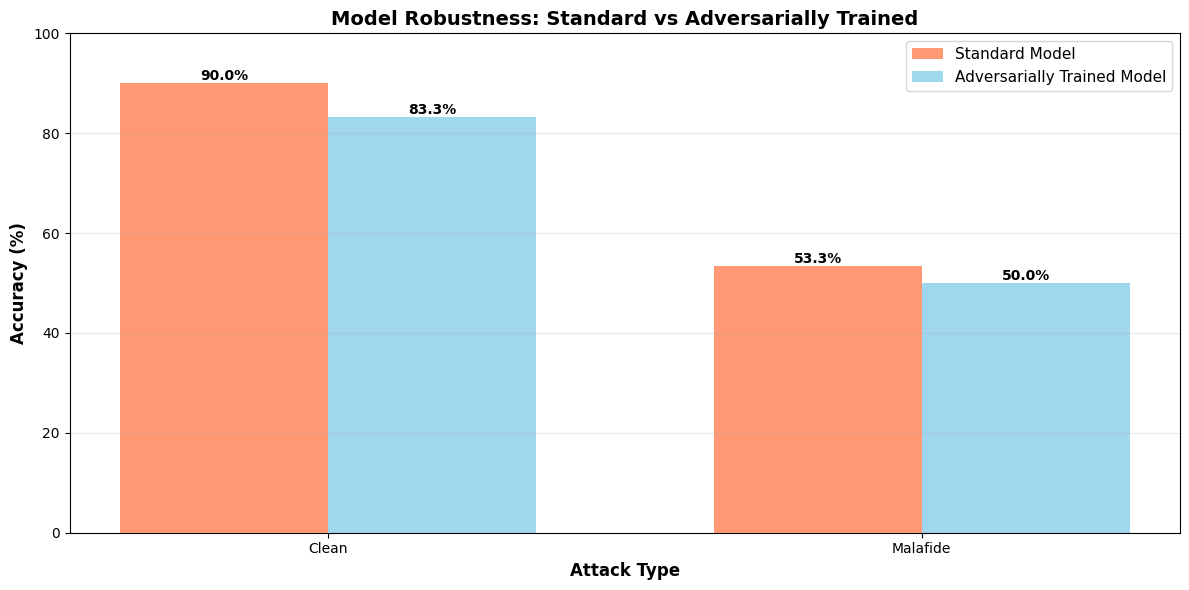


SUMMARY REPORT

Improvement Summary:
----------------------------------------------------------------------

MALAFIDE:
  Before Training: 53.33%
  After Training:  50.00%
  Improvement:     -3.33 percentage points
  Status:          🔴 LIMITED

✅ STEP 7 COMPLETE!


In [23]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ==========================
# CONFIGURATION
# ==========================

WORK_DIR = "./working"  # Change if different

# ==========================
# STEP 7: STANDALONE EVALUATION
# ==========================

print("="*70)
print("STEP 7: EVALUATION AND COMPARISON (STANDALONE)")
print("="*70)

# ==========================
# 1. Load All Models
# ==========================

print("\n1️⃣ Loading models...")

try:
    model_standard = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
    print("   ✓ Standard model loaded")
except Exception as e:
    print(f"   ❌ Error loading standard model: {e}")
    model_standard = None

try:
    model_adv_trained = load_model(os.path.join(WORK_DIR, "deepfake_adv_trained_final.keras"))
    print("   ✓ Adversarially trained model loaded")
except Exception as e:
    print(f"   ❌ Error loading trained model: {e}")
    model_adv_trained = None

# ==========================
# 2. Load Test Data
# ==========================

print("\n2️⃣ Loading test data...")

try:
    X_test = np.load(os.path.join(WORK_DIR, "X_test.npy"))
    y_test = np.load(os.path.join(WORK_DIR, "y_test.npy"))
    print(f"   ✓ Test data loaded: X_test {X_test.shape}, y_test {y_test.shape}")
except Exception as e:
    print(f"   ❌ Error loading test data: {e}")
    X_test = None
    y_test = None

# ==========================
# 3. Load Adversarial Examples
# ==========================

print("\n3️⃣ Loading adversarial examples...")

files_status = {}
adversarial_examples = {}

# FGSM
try:
    X_adv_fgsm = np.load(os.path.join(WORK_DIR, 'X_test_fgsm_adversarial.npy'))
    adversarial_examples['fgsm'] = X_adv_fgsm
    files_status['FGSM'] = '✓'
    print("   ✓ FGSM examples loaded")
except FileNotFoundError:
    files_status['FGSM'] = '✗ MISSING'
    print("   ✗ FGSM examples MISSING")

# PGD
try:
    X_adv_pgd = np.load(os.path.join(WORK_DIR, 'X_test_pgd_adversarial.npy'))
    adversarial_examples['pgd'] = X_adv_pgd
    files_status['PGD'] = '✓'
    print("   ✓ PGD examples loaded")
except FileNotFoundError:
    files_status['PGD'] = '✗ MISSING'
    print("   ✗ PGD examples MISSING")

# 2D-Malafide
try:
    X_adv_malafide = np.load(os.path.join(WORK_DIR, 'X_test_malafide_adversarial.npy'))
    adversarial_examples['malafide'] = X_adv_malafide
    files_status['2D-Malafide'] = '✓'
    print("   ✓ 2D-Malafide examples loaded")
except FileNotFoundError:
    files_status['2D-Malafide'] = '✗ MISSING'
    print("   ✗ 2D-Malafide examples MISSING")

# ==========================
# 4. Verify All Files Exist
# ==========================

print("\n" + "="*70)
print("FILE STATUS:")
print("="*70)

for attack_type, status in files_status.items():
    print(f"  {attack_type}: {status}")

# Check if we have minimum requirements
if len(adversarial_examples) == 0:
    print("\n❌ ERROR: No adversarial examples found!")
    print("   Please ensure you have run:")
    print("   1. FGSM attack (creates X_test_fgsm_adversarial.npy)")
    print("   2. PGD attack (creates X_test_pgd_adversarial.npy)")
    print("   3. 2D-Malafide attack (creates X_test_malafide_adversarial.npy)")
else:
    print(f"\n✓ Found {len(adversarial_examples)} adversarial example files")

# ==========================
# 5. Evaluation Function
# ==========================

def evaluate_models(model_std, model_adv, X_test, y_test, adv_examples):
    """Evaluate and compare models"""
    
    print("\n" + "="*70)
    print("EVALUATING MODEL ROBUSTNESS")
    print("="*70)
    
    results = {}
    
    # Clean baseline
    print("\n📊 CLEAN DATA (No Attack):")
    print("-" * 70)
    
    try:
        std_clean_loss, std_clean_acc = model_std.evaluate(X_test, y_test, verbose=0)
        adv_clean_loss, adv_clean_acc = model_adv.evaluate(X_test, y_test, verbose=0)
        
        print(f"Standard Model:        {std_clean_acc*100:.2f}%")
        print(f"Adversarially Trained: {adv_clean_acc*100:.2f}%")
        print(f"Difference:            {(adv_clean_acc-std_clean_acc)*100:+.2f}%")
        
        results['clean'] = {
            'std': std_clean_acc,
            'adv': adv_clean_acc
        }
    except Exception as e:
        print(f"Error evaluating clean data: {e}")
    
    # Adversarial examples
    for attack_name, X_adv in adv_examples.items():
        attack_name_upper = attack_name.upper()
        print(f"\n📊 {attack_name_upper} ADVERSARIAL ATTACK:")
        print("-" * 70)
        
        try:
            std_adv_loss, std_adv_acc = model_std.evaluate(X_adv, y_test, verbose=0)
            adv_adv_loss, adv_adv_acc = model_adv.evaluate(X_adv, y_test, verbose=0)
            
            improvement = adv_adv_acc - std_adv_acc
            improvement_pct = (improvement / std_adv_acc * 100) if std_adv_acc > 0 else 0
            
            print(f"Standard Model:        {std_adv_acc*100:.2f}%")
            print(f"Adversarially Trained: {adv_adv_acc*100:.2f}%")
            print(f"Absolute Improvement:  {improvement*100:+.2f} percentage points")
            print(f"Relative Improvement:  {improvement_pct:+.1f}%")
            
            results[attack_name] = {
                'std': std_adv_acc,
                'adv': adv_adv_acc
            }
        except Exception as e:
            print(f"Error evaluating {attack_name}: {e}")
    
    return results

# ==========================
# 6. Run Evaluation
# ==========================

if model_standard is not None and model_adv_trained is not None and X_test is not None:
    if len(adversarial_examples) > 0:
        
        results = evaluate_models(
            model_standard, 
            model_adv_trained, 
            X_test, 
            y_test, 
            adversarial_examples
        )
        
        # ==========================
        # 7. Create Comparison Plot
        # ==========================
        
        print("\n" + "="*70)
        print("CREATING COMPARISON PLOT...")
        print("="*70)
        
        try:
            attack_types = list(results.keys())
            std_accuracies = [results[attack]['std'] * 100 for attack in attack_types]
            adv_accuracies = [results[attack]['adv'] * 100 for attack in attack_types]
            
            x = np.arange(len(attack_types))
            width = 0.35
            
            fig, ax = plt.subplots(figsize=(12, 6))
            
            bars1 = ax.bar(x - width/2, std_accuracies, width, 
                          label='Standard Model', alpha=0.8, color='coral')
            bars2 = ax.bar(x + width/2, adv_accuracies, width, 
                          label='Adversarially Trained Model', alpha=0.8, color='skyblue')
            
            ax.set_xlabel('Attack Type', fontsize=12, fontweight='bold')
            ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
            ax.set_title('Model Robustness: Standard vs Adversarially Trained', 
                        fontsize=14, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels([t.capitalize() for t in attack_types])
            ax.legend(fontsize=11)
            ax.set_ylim([0, 100])
            ax.grid(axis='y', alpha=0.3)
            
            # Add value labels on bars
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}%',
                           ha='center', va='bottom', fontsize=10, fontweight='bold')
            
            plt.tight_layout()
            plot_path = os.path.join(WORK_DIR, 'robustness_comparison.png')
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            print(f"\n✓ Plot saved to {plot_path}")
            plt.show()
            
        except Exception as e:
            print(f"Error creating plot: {e}")
        
        # ==========================
        # 8. Summary Report
        # ==========================
        
        print("\n" + "="*70)
        print("SUMMARY REPORT")
        print("="*70)
        
        print("\nImprovement Summary:")
        print("-" * 70)
        
        for attack_name in results.keys():
            if attack_name != 'clean':
                std_acc = results[attack_name]['std'] * 100
                adv_acc = results[attack_name]['adv'] * 100
                improvement = adv_acc - std_acc
                
                print(f"\n{attack_name.upper()}:")
                print(f"  Before Training: {std_acc:.2f}%")
                print(f"  After Training:  {adv_acc:.2f}%")
                print(f"  Improvement:     {improvement:+.2f} percentage points")
                
                if improvement > 30:
                    print(f"  Status:          🟢 EXCELLENT")
                elif improvement > 20:
                    print(f"  Status:          🟢 VERY GOOD")
                elif improvement > 10:
                    print(f"  Status:          🟡 GOOD")
                else:
                    print(f"  Status:          🔴 LIMITED")
        
        print("\n" + "="*70)
        print("✅ STEP 7 COMPLETE!")
        print("="*70)
        
    else:
        print("\n❌ No adversarial examples found. Cannot proceed with evaluation.")
else:
    print("\n❌ Missing required models or test data. Cannot proceed.")


Loading model...
✓ Model loaded

Evaluating model robustness against FGSM attacks...

=== Clean Test (No Attack) ===
Clean Accuracy: 90.00%
Clean Loss: 4.3111

=== Testing FGSM with epsilon=0.01 ===


Generating adversarial (ε=0.01): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:28<00:00,  3.58s/it]


Adversarial Accuracy: 5.00%
Adversarial Loss: 7.5451
Accuracy Drop: 85.00%

=== Testing FGSM with epsilon=0.03 ===


Generating adversarial (ε=0.03): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:29<00:00,  3.69s/it]


Adversarial Accuracy: 10.00%
Adversarial Loss: 7.7405
Accuracy Drop: 80.00%

=== Testing FGSM with epsilon=0.05 ===


Generating adversarial (ε=0.05): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:28<00:00,  3.56s/it]


Adversarial Accuracy: 23.33%
Adversarial Loss: 7.4913
Accuracy Drop: 66.67%

=== Testing FGSM with epsilon=0.1 ===


Generating adversarial (ε=0.1): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:28<00:00,  3.51s/it]


Adversarial Accuracy: 55.00%
Adversarial Loss: 6.5955
Accuracy Drop: 35.00%


💾 SAVING FGSM ADVERSARIAL EXAMPLES
✓ FGSM (ε=0.03) adversarial examples saved to ./working/X_test_fgsm_adversarial.npy
  Shape: (60, 10, 128, 128, 3)
  Size: 0.11 GB

Generating plot...
✓ Plot saved to ./working/fgsm_robustness.png


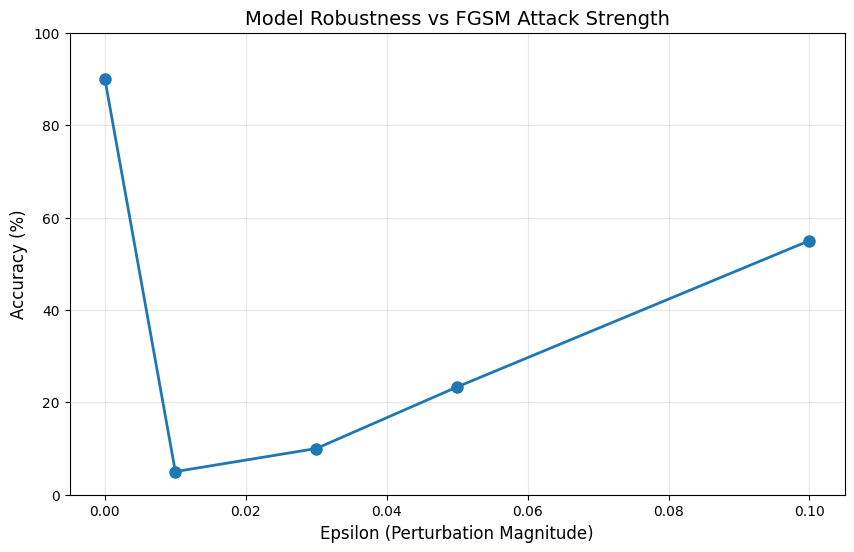


✅ FGSM ATTACK COMPLETE WITH SAVED FILES


In [26]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
from tensorflow.keras.models import load_model
import os

# ==========================
# FGSM Attack Implementation WITH SAVING
# ==========================

def fgsm_attack(model, images, labels, epsilon=0.03):
    """
    Generates adversarial examples using FGSM attack.
    """
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
    
    gradient = tape.gradient(loss, images)
    signed_grad = tf.sign(gradient)
    adversarial_images = images + epsilon * signed_grad
    adversarial_images = tf.clip_by_value(adversarial_images, 0.0, 1.0)
    
    return adversarial_images.numpy()


def evaluate_fgsm_robustness(model, X_test, y_test, epsilons=[0.01, 0.03, 0.05, 0.1]):
    """
    Evaluate model robustness against FGSM attacks with different epsilon values.
    """
    results = {}
    
    print("=== Clean Test (No Attack) ===")
    clean_loss, clean_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Clean Accuracy: {clean_acc * 100:.2f}%")
    print(f"Clean Loss: {clean_loss:.4f}\n")
    
    for eps in epsilons:
        print(f"=== Testing FGSM with epsilon={eps} ===")
        
        X_adv = []
        batch_size = 8
        
        for i in tqdm(range(0, len(X_test), batch_size), desc=f"Generating adversarial (ε={eps})"):
            batch_images = X_test[i:i+batch_size]
            batch_labels = y_test[i:i+batch_size]
            
            adv_batch = fgsm_attack(model, batch_images, batch_labels, epsilon=eps)
            X_adv.append(adv_batch)
        
        X_adv = np.concatenate(X_adv, axis=0)
        
        loss, accuracy = model.evaluate(X_adv, y_test, verbose=0)
        
        results[eps] = {
            'accuracy': accuracy,
            'loss': loss,
            'adversarial_examples': X_adv,
            'accuracy_drop': clean_acc - accuracy
        }
        
        print(f"Adversarial Accuracy: {accuracy * 100:.2f}%")
        print(f"Adversarial Loss: {loss:.4f}")
        print(f"Accuracy Drop: {(clean_acc - accuracy) * 100:.2f}%\n")
    
    return results, clean_acc


# ==========================
# LOAD MODEL
# ==========================

WORK_DIR = "./working"

print("Loading model...")
model = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
print("✓ Model loaded\n")

# ==========================
# RUN FGSM EVALUATION
# ==========================

print("Evaluating model robustness against FGSM attacks...\n")
fgsm_results, clean_accuracy = evaluate_fgsm_robustness(model, X_test, y_test)

# ==========================
# 💾 SAVE ADVERSARIAL EXAMPLES
# ==========================

print("\n" + "="*70)
print("💾 SAVING FGSM ADVERSARIAL EXAMPLES")
print("="*70)

# Save the most important one (ε=0.03)
X_adv_fgsm = fgsm_results[0.03]['adversarial_examples']
np.save(os.path.join(WORK_DIR, 'X_test_fgsm_adversarial.npy'), X_adv_fgsm)
print(f"✓ FGSM (ε=0.03) adversarial examples saved to {WORK_DIR}/X_test_fgsm_adversarial.npy")
print(f"  Shape: {X_adv_fgsm.shape}")
print(f"  Size: {X_adv_fgsm.nbytes / (1024**3):.2f} GB")

# ==========================
# VISUALIZATION
# ==========================

import matplotlib.pyplot as plt

print("\nGenerating plot...")
epsilons = list(fgsm_results.keys())
accuracies = [fgsm_results[eps]['accuracy'] * 100 for eps in epsilons]

plt.figure(figsize=(10, 6))
plt.plot([0] + list(epsilons), [clean_accuracy * 100] + accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('Epsilon (Perturbation Magnitude)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Robustness vs FGSM Attack Strength', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim([0, 100])
plt.savefig(os.path.join(WORK_DIR, 'fgsm_robustness.png'), dpi=300, bbox_inches='tight')
print(f"✓ Plot saved to {WORK_DIR}/fgsm_robustness.png")
plt.show()

print("\n" + "="*70)
print("✅ FGSM ATTACK COMPLETE WITH SAVED FILES")
print("="*70)


In [27]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
from tensorflow.keras.models import load_model
import os

# ==========================
# PGD Attack Implementation WITH SAVING
# ==========================

def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.01, num_iter=10):
    """
    Generates adversarial examples using PGD attack.
    """
    images = tf.Variable(images, dtype=tf.float32)
    labels = tf.cast(labels, tf.float32)
    
    original_images = images.numpy()
    
    for i in range(num_iter):
        with tf.GradientTape() as tape:
            tape.watch(images)
            predictions = model(images, training=False)
            loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
        
        gradient = tape.gradient(loss, images)
        
        signed_grad = tf.sign(gradient)
        images.assign_add(alpha * signed_grad)
        
        perturbation = images - original_images
        perturbation = tf.clip_by_value(perturbation, -epsilon, epsilon)
        images.assign(original_images + perturbation)
        
        images.assign(tf.clip_by_value(images, 0.0, 1.0))
    
    return images.numpy()


def evaluate_pgd_robustness(model, X_test, y_test, epsilon=0.03, alpha=0.01, num_iter=10):
    """
    Evaluate model robustness against PGD attacks.
    """
    print(f"\n=== Testing PGD Attack (eps={epsilon}, alpha={alpha}, iter={num_iter}) ===")
    
    print("\n=== Clean Test (No Attack) ===")
    clean_loss, clean_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Clean Accuracy: {clean_acc * 100:.2f}%")
    print(f"Clean Loss: {clean_loss:.4f}\n")
    
    X_adv = []
    batch_size = 8
    
    for i in tqdm(range(0, len(X_test), batch_size), desc="Generating PGD adversarial examples"):
        batch_images = X_test[i:i+batch_size]
        batch_labels = y_test[i:i+batch_size]
        
        adv_batch = pgd_attack(model, batch_images, batch_labels, 
                               epsilon=epsilon, alpha=alpha, num_iter=num_iter)
        X_adv.append(adv_batch)
    
    X_adv = np.concatenate(X_adv, axis=0)
    
    loss, accuracy = model.evaluate(X_adv, y_test, verbose=0)
    
    print(f"\nAdversarial Accuracy: {accuracy * 100:.2f}%")
    print(f"Adversarial Loss: {loss:.4f}")
    print(f"Accuracy Drop: {(clean_acc - accuracy) * 100:.2f}%")
    
    return X_adv, accuracy, loss


# ==========================
# LOAD MODEL
# ==========================

WORK_DIR = "./working"

print("Loading model...")
model = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
print("✓ Model loaded\n")

# ==========================
# RUN PGD EVALUATION
# ==========================

print("="*70)
print("RUNNING PGD ATTACK EVALUATION")
print("="*70)

X_adv_pgd, pgd_acc, pgd_loss = evaluate_pgd_robustness(
    model, X_test, y_test,
    epsilon=0.03,
    alpha=0.01,
    num_iter=10
)

# ==========================
# 💾 SAVE ADVERSARIAL EXAMPLES
# ==========================

print("\n" + "="*70)
print("💾 SAVING PGD ADVERSARIAL EXAMPLES")
print("="*70)

np.save(os.path.join(WORK_DIR, 'X_test_pgd_adversarial.npy'), X_adv_pgd)
print(f"✓ PGD adversarial examples saved to {WORK_DIR}/X_test_pgd_adversarial.npy")
print(f"  Shape: {X_adv_pgd.shape}")
print(f"  Size: {X_adv_pgd.nbytes / (1024**3):.2f} GB")

print("\n" + "="*70)
print("✅ PGD ATTACK COMPLETE WITH SAVED FILES")
print("="*70)


Loading model...
✓ Model loaded

RUNNING PGD ATTACK EVALUATION

=== Testing PGD Attack (eps=0.03, alpha=0.01, iter=10) ===

=== Clean Test (No Attack) ===
Clean Accuracy: 90.00%
Clean Loss: 4.3111



Generating PGD adversarial examples: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:51<00:00, 36.40s/it]



Adversarial Accuracy: 0.00%
Adversarial Loss: 14.4263
Accuracy Drop: 90.00%

💾 SAVING PGD ADVERSARIAL EXAMPLES
✓ PGD adversarial examples saved to ./working/X_test_pgd_adversarial.npy
  Shape: (60, 10, 128, 128, 3)
  Size: 0.11 GB

✅ PGD ATTACK COMPLETE WITH SAVED FILES


STEP 7: EVALUATION AND COMPARISON (STANDALONE)

1️⃣ Loading models...
   ✓ Standard model loaded
   ✓ Adversarially trained model loaded

2️⃣ Loading test data...
   ✓ Test data loaded: X_test (60, 10, 128, 128, 3), y_test (60, 2)

3️⃣ Loading adversarial examples...
   ✓ FGSM examples loaded
   ✓ PGD examples loaded
   ✓ 2D-Malafide examples loaded

FILE STATUS:
  FGSM: ✓
  PGD: ✓
  2D-Malafide: ✓

✓ Found 3 adversarial example files

EVALUATING MODEL ROBUSTNESS

📊 CLEAN DATA (No Attack):
----------------------------------------------------------------------
Standard Model:        90.00%
Adversarially Trained: 83.33%
Difference:            -6.67%

📊 FGSM ADVERSARIAL ATTACK:
----------------------------------------------------------------------
Standard Model:        10.00%
Adversarially Trained: 88.33%
Absolute Improvement:  +78.33 percentage points
Relative Improvement:  +783.3%

📊 PGD ADVERSARIAL ATTACK:
----------------------------------------------------------------------
Standard

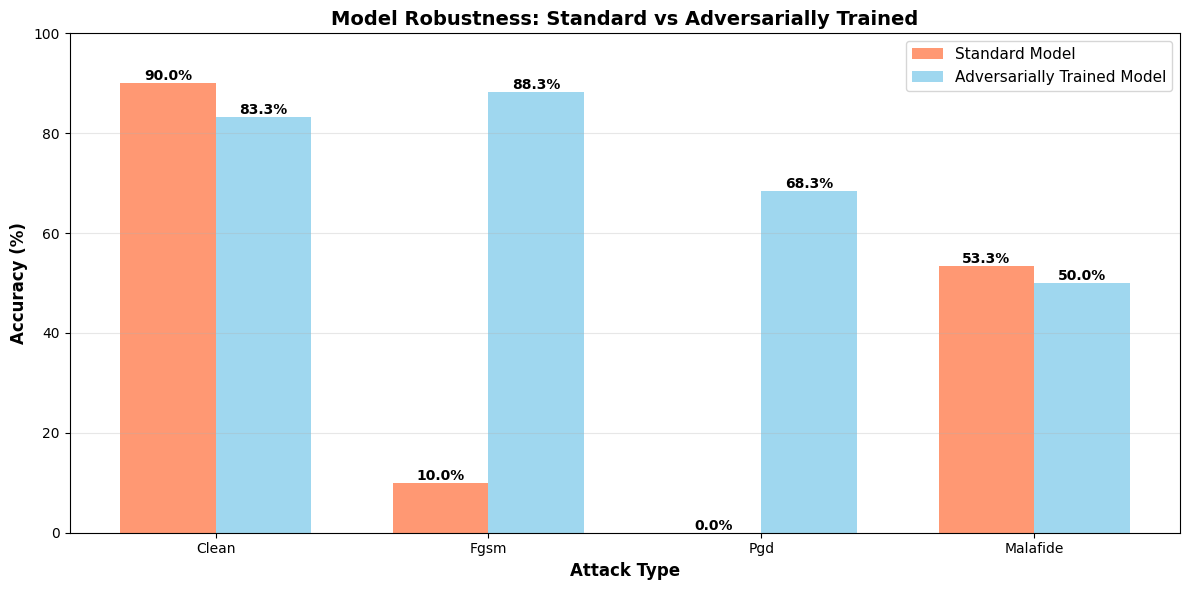


SUMMARY REPORT

Improvement Summary:
----------------------------------------------------------------------

FGSM:
  Before Training: 10.00%
  After Training:  88.33%
  Improvement:     +78.33 percentage points
  Status:          🟢 EXCELLENT

PGD:
  Before Training: 0.00%
  After Training:  68.33%
  Improvement:     +68.33 percentage points
  Status:          🟢 EXCELLENT

MALAFIDE:
  Before Training: 53.33%
  After Training:  50.00%
  Improvement:     -3.33 percentage points
  Status:          🔴 LIMITED

✅ STEP 7 COMPLETE!


In [28]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ==========================
# CONFIGURATION
# ==========================

WORK_DIR = "./working"  # Change if different

# ==========================
# STEP 7: STANDALONE EVALUATION
# ==========================

print("="*70)
print("STEP 7: EVALUATION AND COMPARISON (STANDALONE)")
print("="*70)

# ==========================
# 1. Load All Models
# ==========================

print("\n1️⃣ Loading models...")

try:
    model_standard = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
    print("   ✓ Standard model loaded")
except Exception as e:
    print(f"   ❌ Error loading standard model: {e}")
    model_standard = None

try:
    model_adv_trained = load_model(os.path.join(WORK_DIR, "deepfake_adv_trained_final.keras"))
    print("   ✓ Adversarially trained model loaded")
except Exception as e:
    print(f"   ❌ Error loading trained model: {e}")
    model_adv_trained = None

# ==========================
# 2. Load Test Data
# ==========================

print("\n2️⃣ Loading test data...")

try:
    X_test = np.load(os.path.join(WORK_DIR, "X_test.npy"))
    y_test = np.load(os.path.join(WORK_DIR, "y_test.npy"))
    print(f"   ✓ Test data loaded: X_test {X_test.shape}, y_test {y_test.shape}")
except Exception as e:
    print(f"   ❌ Error loading test data: {e}")
    X_test = None
    y_test = None

# ==========================
# 3. Load Adversarial Examples
# ==========================

print("\n3️⃣ Loading adversarial examples...")

files_status = {}
adversarial_examples = {}

# FGSM
try:
    X_adv_fgsm = np.load(os.path.join(WORK_DIR, 'X_test_fgsm_adversarial.npy'))
    adversarial_examples['fgsm'] = X_adv_fgsm
    files_status['FGSM'] = '✓'
    print("   ✓ FGSM examples loaded")
except FileNotFoundError:
    files_status['FGSM'] = '✗ MISSING'
    print("   ✗ FGSM examples MISSING")

# PGD
try:
    X_adv_pgd = np.load(os.path.join(WORK_DIR, 'X_test_pgd_adversarial.npy'))
    adversarial_examples['pgd'] = X_adv_pgd
    files_status['PGD'] = '✓'
    print("   ✓ PGD examples loaded")
except FileNotFoundError:
    files_status['PGD'] = '✗ MISSING'
    print("   ✗ PGD examples MISSING")

# 2D-Malafide
try:
    X_adv_malafide = np.load(os.path.join(WORK_DIR, 'X_test_malafide_adversarial.npy'))
    adversarial_examples['malafide'] = X_adv_malafide
    files_status['2D-Malafide'] = '✓'
    print("   ✓ 2D-Malafide examples loaded")
except FileNotFoundError:
    files_status['2D-Malafide'] = '✗ MISSING'
    print("   ✗ 2D-Malafide examples MISSING")

# ==========================
# 4. Verify All Files Exist
# ==========================

print("\n" + "="*70)
print("FILE STATUS:")
print("="*70)

for attack_type, status in files_status.items():
    print(f"  {attack_type}: {status}")

# Check if we have minimum requirements
if len(adversarial_examples) == 0:
    print("\n❌ ERROR: No adversarial examples found!")
    print("   Please ensure you have run:")
    print("   1. FGSM attack (creates X_test_fgsm_adversarial.npy)")
    print("   2. PGD attack (creates X_test_pgd_adversarial.npy)")
    print("   3. 2D-Malafide attack (creates X_test_malafide_adversarial.npy)")
else:
    print(f"\n✓ Found {len(adversarial_examples)} adversarial example files")

# ==========================
# 5. Evaluation Function
# ==========================

def evaluate_models(model_std, model_adv, X_test, y_test, adv_examples):
    """Evaluate and compare models"""
    
    print("\n" + "="*70)
    print("EVALUATING MODEL ROBUSTNESS")
    print("="*70)
    
    results = {}
    
    # Clean baseline
    print("\n📊 CLEAN DATA (No Attack):")
    print("-" * 70)
    
    try:
        std_clean_loss, std_clean_acc = model_std.evaluate(X_test, y_test, verbose=0)
        adv_clean_loss, adv_clean_acc = model_adv.evaluate(X_test, y_test, verbose=0)
        
        print(f"Standard Model:        {std_clean_acc*100:.2f}%")
        print(f"Adversarially Trained: {adv_clean_acc*100:.2f}%")
        print(f"Difference:            {(adv_clean_acc-std_clean_acc)*100:+.2f}%")
        
        results['clean'] = {
            'std': std_clean_acc,
            'adv': adv_clean_acc
        }
    except Exception as e:
        print(f"Error evaluating clean data: {e}")
    
    # Adversarial examples
    for attack_name, X_adv in adv_examples.items():
        attack_name_upper = attack_name.upper()
        print(f"\n📊 {attack_name_upper} ADVERSARIAL ATTACK:")
        print("-" * 70)
        
        try:
            std_adv_loss, std_adv_acc = model_std.evaluate(X_adv, y_test, verbose=0)
            adv_adv_loss, adv_adv_acc = model_adv.evaluate(X_adv, y_test, verbose=0)
            
            improvement = adv_adv_acc - std_adv_acc
            improvement_pct = (improvement / std_adv_acc * 100) if std_adv_acc > 0 else 0
            
            print(f"Standard Model:        {std_adv_acc*100:.2f}%")
            print(f"Adversarially Trained: {adv_adv_acc*100:.2f}%")
            print(f"Absolute Improvement:  {improvement*100:+.2f} percentage points")
            print(f"Relative Improvement:  {improvement_pct:+.1f}%")
            
            results[attack_name] = {
                'std': std_adv_acc,
                'adv': adv_adv_acc
            }
        except Exception as e:
            print(f"Error evaluating {attack_name}: {e}")
    
    return results

# ==========================
# 6. Run Evaluation
# ==========================

if model_standard is not None and model_adv_trained is not None and X_test is not None:
    if len(adversarial_examples) > 0:
        
        results = evaluate_models(
            model_standard, 
            model_adv_trained, 
            X_test, 
            y_test, 
            adversarial_examples
        )
        
        # ==========================
        # 7. Create Comparison Plot
        # ==========================
        
        print("\n" + "="*70)
        print("CREATING COMPARISON PLOT...")
        print("="*70)
        
        try:
            attack_types = list(results.keys())
            std_accuracies = [results[attack]['std'] * 100 for attack in attack_types]
            adv_accuracies = [results[attack]['adv'] * 100 for attack in attack_types]
            
            x = np.arange(len(attack_types))
            width = 0.35
            
            fig, ax = plt.subplots(figsize=(12, 6))
            
            bars1 = ax.bar(x - width/2, std_accuracies, width, 
                          label='Standard Model', alpha=0.8, color='coral')
            bars2 = ax.bar(x + width/2, adv_accuracies, width, 
                          label='Adversarially Trained Model', alpha=0.8, color='skyblue')
            
            ax.set_xlabel('Attack Type', fontsize=12, fontweight='bold')
            ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
            ax.set_title('Model Robustness: Standard vs Adversarially Trained', 
                        fontsize=14, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels([t.capitalize() for t in attack_types])
            ax.legend(fontsize=11)
            ax.set_ylim([0, 100])
            ax.grid(axis='y', alpha=0.3)
            
            # Add value labels on bars
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}%',
                           ha='center', va='bottom', fontsize=10, fontweight='bold')
            
            plt.tight_layout()
            plot_path = os.path.join(WORK_DIR, 'robustness_comparison.png')
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            print(f"\n✓ Plot saved to {plot_path}")
            plt.show()
            
        except Exception as e:
            print(f"Error creating plot: {e}")
        
        # ==========================
        # 8. Summary Report
        # ==========================
        
        print("\n" + "="*70)
        print("SUMMARY REPORT")
        print("="*70)
        
        print("\nImprovement Summary:")
        print("-" * 70)
        
        for attack_name in results.keys():
            if attack_name != 'clean':
                std_acc = results[attack_name]['std'] * 100
                adv_acc = results[attack_name]['adv'] * 100
                improvement = adv_acc - std_acc
                
                print(f"\n{attack_name.upper()}:")
                print(f"  Before Training: {std_acc:.2f}%")
                print(f"  After Training:  {adv_acc:.2f}%")
                print(f"  Improvement:     {improvement:+.2f} percentage points")
                
                if improvement > 30:
                    print(f"  Status:          🟢 EXCELLENT")
                elif improvement > 20:
                    print(f"  Status:          🟢 VERY GOOD")
                elif improvement > 10:
                    print(f"  Status:          🟡 GOOD")
                else:
                    print(f"  Status:          🔴 LIMITED")
        
        print("\n" + "="*70)
        print("✅ STEP 7 COMPLETE!")
        print("="*70)
        
    else:
        print("\n❌ No adversarial examples found. Cannot proceed with evaluation.")
else:
    print("\n❌ Missing required models or test data. Cannot proceed.")
